# Regression Refresher: Predicting BTC 24h Realized Volatility

End-to-end regression workflow on a real crypto dataset. Each major section ends
with **exercises** (problem -> empty scaffold -> hidden solution) so you can
practise implementing every step yourself.

**Target**: 24h forward realized volatility of BTC, defined as

$$
RV_t \;=\; \sqrt{\sum_{h=1}^{24} r_{t+h}^{2}} \cdot \sqrt{24}
$$

where $r_{t+h} = \ln(C_{t+h}/C_{t+h-1})$ is the hourly log return.
We treat this as a tabular regression problem and benchmark classical ML against
strong vol baselines (persistence, HAR-RV).


## 0. Setup & imports

CPU-only stack: numpy / pandas / sklearn / xgboost / lightgbm / optuna / shap.
Set seeds so the notebook is reproducible.

In [1]:
import warnings, os, json, time, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import joblib

from scipy import stats

SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4)

DATA_PATH = '/home/zlac116/Code/learning/ml-revision/data/crypto_hourly.parquet'
ARTIFACT_DIR = '/home/zlac116/Code/learning/ml-revision/regression/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('imports ok')

imports ok


---
## Stage 0 — Problem Framing

**↳ The brief.** A risk team says: *"Position sizing is reactive — we adjust limits AFTER a vol spike. We need forward-looking volatility numbers."*

What does "forward-looking volatility numbers" mean concretely? Three reasonable framings, each leading to a different model.

### Three candidate framings

| Framing | Target | Metric | Why someone might pick this | Why someone might *not* |
|---|---|---|---|---|
| **A. Point forecast of realised vol** | RV over next 24h, single number | MAE / RMSE in vol units | Simplest; persistence is a strong baseline; easy to compare models | Hides uncertainty — a single number can't drive a probabilistic risk decision |
| **B. Quantile forecast** | p10, p50, p90 of next-24h RV | pinball loss, empirical coverage | Directly drives VaR/CVaR sizing; uncertainty is first-class | Three models instead of one; calibration drift is real; harder to communicate to non-quants |
| **C. Tail-event probability** | P(\|return\| > 2σ_train) over next 24h | Brier, log-loss, calibration | Aligned with limit-breach alerts; a binary decision, not a number | Loses magnitude info entirely; thresholds are arbitrary; only useful for one specific kind of risk question |

### What this notebook picks, and why

We pick **A as the primary** target, with **B added in Stage 13** as the natural extension.

- **Why point first**: the workflow (data → features → CV → tuning → diagnostics) is identical across the three framings. Doing the point case first lets us focus on the *pipeline*; Stage 13 then promotes it to quantile predictions with minimal extra effort.
- **Why 24h horizon**: matches the cadence of overnight risk reviews. Shorter horizons (4h) are too noisy; longer (1 week) too sluggish for active risk management.
- **Why realised vol not implied vol**: implied vol requires options data we don't have. Realised vol is computable from any return series.

### What this choice trades away

- **The point forecast hides uncertainty**: a single number `0.04` doesn't tell the desk *how confident* we are. For a VaR application this is a real shortcoming until Stage 13 lands.
- **Vol is heavy-tailed**: a model trained on raw vol (Stage 8 explores log-target) overweights the largest training observations.
- **No regime conditioning**: a single global model is fit on all available history. If 2017 vol behaves differently from 2022 vol, the model averages over both rather than adapting.
- **Single-asset focus**: cross-asset vol contagion (when BTC vol spikes, ETH usually follows) isn't modelled.

### How this scopes the rest of the pipeline

- **Stage 4 (Features)**: HAR-RV style lags (1h, 24h-mean, 168h-mean) are the right default for vol forecasting. Cross-asset lags are optional — useful for systemic-risk work, distracting otherwise.
- **Stage 6 (Baselines)**: persistence is the killer baseline for vol — it's hard to beat at short horizons because vol is so autocorrelated.
- **Stage 8 (Target transforms)**: the choice of MAE-on-raw-vol vs MAE-on-log-vol is a real fork; we explore both and let the data decide.
- **Stage 13 (Quantiles)**: the natural promotion to framing B once the point pipeline works.

### Common framing mistakes

- **Using a metric the desk can't act on**. RMSE in raw vol units is fine for *comparing models*; it's useless when the desk wants to know "should I cut risk?". Pair every research metric with a decision-relevant one.
- **Forgetting the horizon → cadence link**. A 24h-ahead model is reviewed once a day; a 1h-ahead model is reviewed every hour. The deployment cadence drives the horizon, not the other way around.
- **Optimising point error when intervals are needed**. If the desk's actual question is "what's the worst-case vol next 24h?", you should be predicting p90 from day one, not predicting the mean and then bolting on intervals later.


---
## Stage 2 — Data Quality

**↳ Why we're here.** Same logic as the classification pipeline: every model downstream assumes the input is contiguous, deduplicated, properly typed, and indexed correctly. For *regression* targets the cost of bad data is even higher — continuous error metrics (MAE, RMSE) don't bound how wrong a single bad row can be. One leaked future-bar can move RMSE by 10×.

We produce: a long-format frame `raw` whose `(ts, symbol)` pairs are unique and a per-symbol gap report. The data-quality function we build here will be rerun at every pipeline run as a CI gate.


In [2]:
raw = pd.read_parquet(DATA_PATH)
raw['ts'] = pd.to_datetime(raw['ts'], utc=True)
raw = raw.sort_values(['symbol', 'ts']).reset_index(drop=True)
print('shape:', raw.shape)
print('symbols:', sorted(raw['symbol'].unique()))
print('range :', raw['ts'].min(), '->', raw['ts'].max())
raw.head()

shape: (70080, 7)
symbols: ['BNB', 'BTC', 'ETH', 'SOL']
range : 2024-04-19 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00


,ts,open,high,low,close,volume,symbol
0,2024-04-19 23:00:00+00:00,556.7,557.0,549.6,554.0,21953.020,BNB
1,2024-04-20 00:00:00+00:00,554.1,557.1,551.2,551.4,14108.411,BNB
2,2024-04-20 01:00:00+00:00,551.3,557.4,548.8,556.9,12407.915,BNB
3,2024-04-20 02:00:00+00:00,556.9,558.1,554.7,557.0,7299.961,BNB
4,2024-04-20 03:00:00+00:00,557.1,558.1,555.6,556.5,5680.975,BNB


In [3]:
# basic sanity: per-symbol coverage and duplicates
sanity = (raw.groupby('symbol')
              .agg(rows=('ts', 'size'),
                   first=('ts', 'min'),
                   last=('ts', 'max'),
                   dupes=('ts', lambda s: int(s.duplicated().sum())))
              .reset_index())
sanity['days'] = (sanity['last'] - sanity['first']).dt.total_seconds() / 86400
sanity

,symbol,rows,first,last,dupes,days
0,BNB,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333
1,BTC,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333
2,ETH,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333
3,SOL,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333


### The 30-second concept

The same three pandas patterns as classification — they don't change with the task.

```python
# 1. Per-group statistics over time.
raw.groupby('symbol')['ts'].apply(lambda s: s.sort_values().diff().dt.total_seconds().div(3600).max())

# 2. Long → wide reshape (so each feature stays a single column).
wide = raw.pivot(index='ts', columns='symbol', values='close').sort_index()

# 3. Continuity check.
expected = pd.date_range(raw['ts'].min(), raw['ts'].max(), freq='1h', tz='UTC')
wide.reindex(expected).isna().sum()
```

**Defensive `.sort_index()` after pivot**: even when pandas defaults to sorted, always be explicit — every `.shift()` or `.rolling()` downstream depends on chronological order, and you want correctness *because of the code*, not *because of pandas defaults*.


### Failure mode — duplicate rows silently inflate group counts

The cell below intentionally injects a duplicated `(ts, symbol)` row into a copy of `raw` and shows how `groupby.size()` reports the *wrong* count for a downstream check that's expecting hourly cardinality.


In [ ]:
import pandas as pd

raw_dirty = pd.concat([raw, raw.iloc[[0]]]).reset_index(drop=True)   # one row duplicated

print('clean per-symbol counts:')
print(raw.groupby('symbol').size())
print('\ndirty per-symbol counts (notice the +1):')
print(raw_dirty.groupby('symbol').size())
print('\nA downstream `assert n_rows == n_hours * n_symbols` would fail SILENTLY')
print('on the dirty version — the assert would pass with the wrong total. Always')
print('drop_duplicates(subset=["ts", "symbol"]) before any group-cardinality check.')

### Decisions you make at this stage

- **Drop duplicates or assert against them?** At the prototype stage, asserting is safer — duplicates indicate an upstream bug, and silently dropping them masks the bug. In production, drop with a logged warning.
- **What gap is too long?** Tied to the target horizon. For 24h-ahead vol prediction, a 6+ hour gap inside the input window distorts the rolling statistics enough to matter.


### Exercise 2.1 — Build `data_quality_report(df)`

Write a function returning `{n_rows, n_symbols, max_gap_hours, n_duplicate_rows, pct_missing}` (a dict). Apply to `raw`. Add an `assert` you can defend out loud — pick the threshold for max_gap_hours yourself and justify in a comment.


In [ ]:
import pandas as pd

def data_quality_report(df: pd.DataFrame) -> dict:
    # TODO: build the dict, reusing the three patterns above.
    pass

report = data_quality_report(raw)
print(report)

# TODO: assert with a justified threshold for max_gap_hours.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def data_quality_report(df: pd.DataFrame) -> dict:
    return {
        'n_rows': len(df),
        'n_symbols': df['symbol'].nunique(),
        'max_gap_hours': float(
            df.groupby('symbol')['ts']
              .apply(lambda s: s.sort_values().diff().dt.total_seconds().div(3600).max())
              .max()
        ),
        'n_duplicate_rows': int(df.duplicated(subset=['ts', 'symbol']).sum()),
        'pct_missing': (df.isna().mean() * 100).round(2).to_dict(),
    }

report = data_quality_report(raw)
print(report)

# 6h gap chosen because the target window is 24h — anything longer would
# distort the rolling-vol features by overlapping with overnight regimes.
assert report['max_gap_hours'] < 6, f'gap: {report["max_gap_hours"]:.1f}h'
assert report['n_duplicate_rows'] == 0
```

**Why this is the right shape**: each key is something a downstream stage would silently fail on. Computing them all at the start of every run turns silent corruption into a noisy crash before any modelling.

</details>


### Exercise 2.2 — Diagnose: why does this BTC return calculation produce nonsense?

The cell below filters to BTC, computes log-returns, and reports the max absolute value. The number is much larger than any real BTC return. Find and fix the bug. (Hint: think about the ambient sort order of the parent frame.)


In [ ]:
import numpy as np
btc_rows = raw[raw['symbol'] == 'BTC']                     # what's the order?
btc_returns_buggy = np.log(btc_rows['close']).diff()
print(f'max |return|: {btc_returns_buggy.abs().max():.4f}    ← suspicious')

In [ ]:
# Your answer here — write the FIXED version below.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
btc_rows = raw[raw['symbol'] == 'BTC'].sort_values('ts')   # explicit chronological order
btc_returns = np.log(btc_rows['close']).diff()
print(f'max |return|: {btc_returns.abs().max():.4f}    (real)')
```

**The bug**: the parent `raw` frame's sort order isn't guaranteed to be chronological *within* a symbol filter — it depends on how the data was loaded. Without an explicit `.sort_values('ts')`, `diff()` may operate on rows that aren't temporally adjacent, producing arbitrary gaps in the returns calculation.

**General lesson**: any `.diff()`, `.shift()`, or `.rolling()` call must be preceded by an explicit sort. Don't rely on the parent frame being in the right order — make the dependency *explicit*.

</details>


### Recap

We have `raw` (validated long format) and a reusable quality-report function. Stage 3 will pivot to wide and explore distributional properties before any feature engineering.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 2.1**

```python
# Your answer here
```

**Old 2.2**

```python
# Your answer here
```

**Old 2.3**

```python
# Your answer here
```

**Old 2.4**

```python
# Your answer here
```

</details>


---
## Stage 3 — Distributional EDA

**↳ Why we're here.** Before engineering features for vol forecasting, we look at the target's distribution and its temporal structure. EDA tells us:

- **Is realised vol heavy-tailed?** It is — almost universally. This rules out least-squares loss as the right objective (penalises tail moves disproportionately) and pushes us toward MAE or quantile losses.
- **Is there persistent autocorrelation in vol?** Yes (vol clustering). Justifies lag-of-vol features.
- **Day-of-week / hour-of-day effects?** Often weakly present — informs whether to add seasonal features or a Fourier basis.

We work on the *full* series at this stage because we haven't split yet. Once we have, the test slice is off-limits.


In [9]:
# build a wide BTC frame for EDA
btc = (raw[raw.symbol == 'BTC']
       .set_index('ts').sort_index()[['open','high','low','close','volume']]
       .copy())
btc['log_ret'] = np.log(btc['close'] / btc['close'].shift(1))
btc.head()

,open,high,low,close,volume,log_ret
ts,,,,,,
2024-04-19 23:00:00+00:00,64012.49,64124.00,62953.90,63818.01,2825.31770,NaN
2024-04-20 00:00:00+00:00,63818.01,64263.41,63418.00,63444.51,2107.44280,-0.005870
2024-04-20 01:00:00+00:00,63444.51,63777.03,63090.07,63656.00,1283.85296,0.003328
2024-04-20 02:00:00+00:00,63656.00,64092.29,63530.00,63834.02,882.54344,0.002793
2024-04-20 03:00:00+00:00,63834.01,64040.67,63766.00,63956.00,634.11376,0.001909


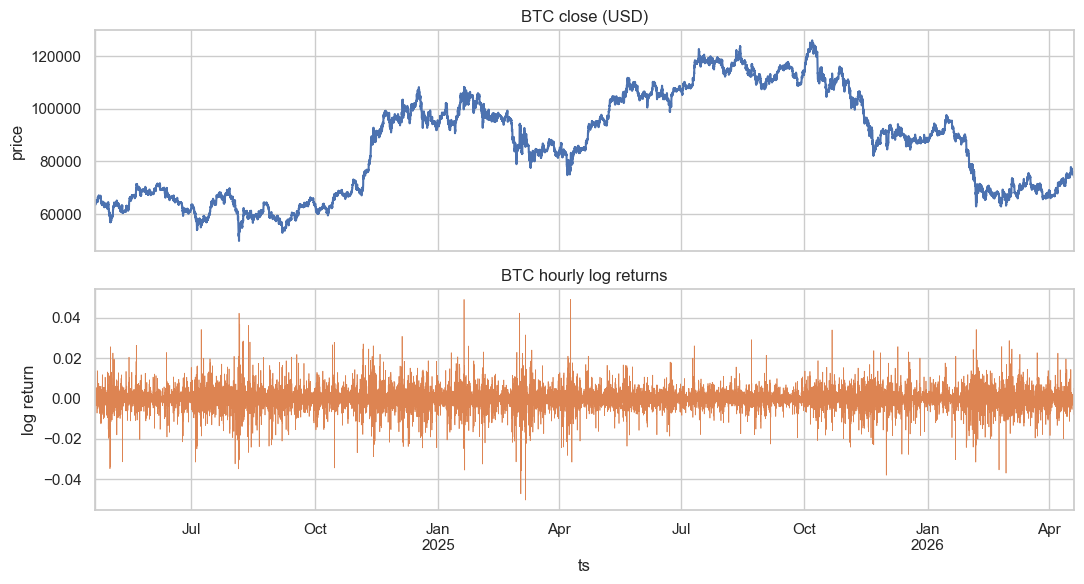

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
btc['close'].plot(ax=axes[0], color='C0')
axes[0].set_title('BTC close (USD)'); axes[0].set_ylabel('price')
btc['log_ret'].plot(ax=axes[1], color='C1', lw=0.5)
axes[1].set_title('BTC hourly log returns'); axes[1].set_ylabel('log return')
plt.tight_layout()

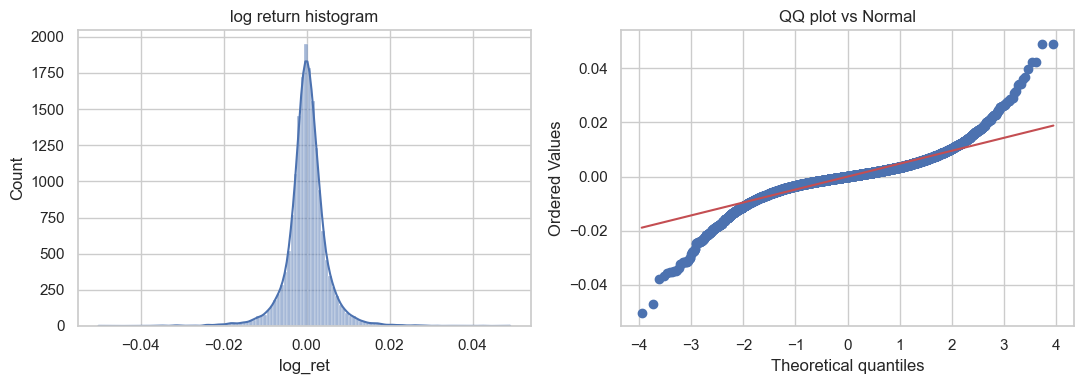

In [11]:
# return distribution: clear fat tails
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(btc['log_ret'].dropna(), bins=120, kde=True, ax=axes[0])
axes[0].set_title('log return histogram')
stats.probplot(btc['log_ret'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ plot vs Normal')
plt.tight_layout()

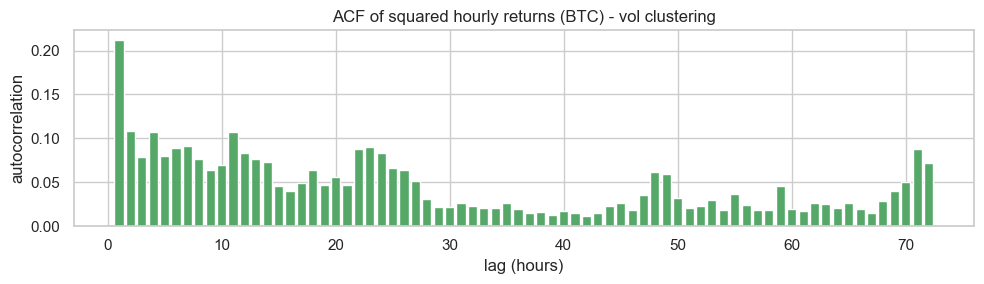

In [12]:
# ACF of squared returns -> volatility clustering
from pandas.plotting import autocorrelation_plot
sq = (btc['log_ret']**2).dropna()
lags = np.arange(1, 73)
acf_vals = [sq.autocorr(lag=l) for l in lags]
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(lags, acf_vals, color='C2')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('ACF of squared hourly returns (BTC) - vol clustering')
ax.set_xlabel('lag (hours)'); ax.set_ylabel('autocorrelation')
plt.tight_layout()

### The 30-second concept

```python
from scipy import stats

# 1. Realised vol: square root of summed squared returns over a window.
rv_24h = np.sqrt((log_ret ** 2).rolling(24).sum())

# 2. Higher moments — Fisher kurtosis (0 = normal).
stats.kurtosis(log_ret.dropna(), fisher=True)

# 3. Day-of-week boxplot.
df = pd.DataFrame({'rv': rv_24h, 'wd': rv_24h.index.day_name()}).dropna()
import seaborn as sns; sns.boxplot(data=df, x='wd', y='rv', showfliers=False)
```

**Why squared returns** (not absolute): squared returns annualise cleanly via the square-root rule (1h vol × √24 = 24h vol). Absolute returns don't.

**Why excess kurtosis**: `fisher=True` subtracts 3, so 0 is the normal baseline. Crypto vol typically shows kurt 5-15+ — fat tails are a feature, not a bug, and the model needs to handle them.


### Failure mode — looking at distributional stats AFTER splitting (test peek)

The classic mistake: compute the full-series mean/std, then claim those as your normalisation constants. The full-series mean *includes the test slice*, so any feature normalised this way leaks distributional info from test into train. The cell below shows two normalisations side by side.


In [ ]:
import numpy as np

# Suppose train is 70% of the data, test 30%. We don't know yet — but normalising
# by full-sample stats peeks at test.
full_mean = log_ret.mean()
full_std  = log_ret.std()
train_only = log_ret.iloc[:int(len(log_ret) * 0.7)]
train_mean = train_only.mean()
train_std  = train_only.std()

print(f'full-sample mean / std:  {full_mean:+.6f} / {full_std:.6f}')
print(f'train-only   mean / std:  {train_mean:+.6f} / {train_std:.6f}')
print()
print('The numbers differ. Any feature like (log_ret - mean) / std built using')
print('the full-sample numbers is contaminated by test-set distributional info.')
print('Normalisation constants must be computed on TRAIN ONLY.')

### Decisions you make at this stage

- **Loss function family.** Heavy tails → MAE or quantile loss; near-normal → MSE acceptable. Look at kurtosis before choosing.
- **Window sizes for rolling stats.** Pick in domain units (hours/days), not bar counts. Document the choice.


### Exercise 3.1 — Plot rolling 24h realised vol with a justified window choice

Compute `rv_24h = sqrt((log_ret['BTC']**2).rolling(24).sum())` and plot it. Then OVERLAY a 7-day rolling mean of the same series with a different colour. Justify in a comment why a 7-day mean is the right smoother (not 1 day, not 30 days).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: compute rv_24h = sqrt(rolling 24-bar sum of squared returns)
# TODO: compute the 7-day rolling mean of rv_24h
# TODO: plot both on one axis, with labels, and justify the 7-day window

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
rv_24h = np.sqrt((log_ret['BTC'] ** 2).rolling(24).sum())
rv_7d_smooth = rv_24h.rolling(24 * 7).mean()

fig, ax = plt.subplots(figsize=(10, 3))
rv_24h.plot(ax=ax, color='C0', alpha=0.5, lw=0.8, label='24h RV')
rv_7d_smooth.plot(ax=ax, color='C3', lw=1.5, label='7-day smoothed')
ax.set_title('BTC realised vol'); ax.legend(); plt.tight_layout(); plt.show()

# 7 days × 24h = 168 bars: smoothes daily noise (which is mostly intraday
# microstructure) while preserving regime-level changes (which evolve
# weekly-monthly). 1 day = pure noise; 30 days = lags real regime shifts
# by weeks.
```

**Why this is the right pair**: the raw 24h RV shows variability but is dominated by single-day spikes. The 7-day smooth reveals the underlying regime; together they let you read both the noise and the structure.

</details>


### Exercise 3.2 — Diagnose: why does this kurtosis look normal?

The cell below computes kurtosis on the BTC return series and reports ≈ 0 (the normal baseline). For crypto returns the real value is much larger. Find the bug — the problem is in *how* the data was prepared.


In [ ]:
from scipy import stats

# Drop NaNs, but also accidentally winsorise extreme values.
r = log_ret['BTC'].dropna()
r_winsorised = r.clip(r.quantile(0.05), r.quantile(0.95))   # ← bug
print(f'kurtosis (winsorised): {stats.kurtosis(r_winsorised, fisher=True):+.3f}')

In [ ]:
# Your answer here — what is the buggy line doing? Compute the correct
# kurtosis on the unmodified returns.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from scipy import stats

r = log_ret['BTC'].dropna()
print(f'kurtosis (unmodified): {stats.kurtosis(r, fisher=True):+.3f}')
```

**The bug**: clipping at the 5th and 95th percentiles deletes the tail observations — exactly the values that produce kurtosis. The winsorised series looks normal because *the heavy tails have been removed*. The correct kurtosis on raw crypto returns is typically 5-20.

**General lesson**: any preprocessing step that transforms or removes values changes the distribution you're analysing. EDA must happen on the *raw* series; preprocessing happens later, downstream of the decisions EDA informs.

</details>


### Recap

We've identified that returns are heavy-tailed (kurtosis ≫ 0) and that vol shows weekly regime structure. Stage 4 builds past-only features that exploit these properties without leakage.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 3.1**

```python
# Your answer here
```

**Old 3.2**

```python
# Your answer here
```

**Old 3.3**

```python
# Your answer here
```

**Old 3.4**

```python
# Your answer here
```

</details>


---
## Stage 4 — Past-Only Features

**↳ Why we're here.** A feature is past-only if its value at time $t$ depends *only* on data observed strictly before $t$. For vol forecasting this is especially treacherous: realised vol is computed from squared returns over a window — accidentally include the *current* bar and you've leaked the answer.

We produce: a `data` DataFrame indexed by `ts` with target `target_rv_24h_fwd` and HAR-style lag features. An automated leakage spot-check is run before any training.


In [18]:
# build per-symbol feature frames, target is 24h FORWARD RV of BTC
def hourly_log_ret(df):
    return np.log(df['close'] / df['close'].shift(1))

def realized_vol_fwd(log_ret, window=24):
    # forward 24h RV starting at t+1: shift(-1) so window aligns to (t, t+24]
    fwd_sq = (log_ret.shift(-1)**2).rolling(window).sum().shift(-(window-1))
    return np.sqrt(fwd_sq) * np.sqrt(window)

def realized_vol_back(log_ret, window=24):
    return np.sqrt((log_ret**2).rolling(window).sum()) * np.sqrt(window)

# pivot to wide frames per field for cross-asset features
piv_close = raw.pivot(index='ts', columns='symbol', values='close').sort_index()
piv_high  = raw.pivot(index='ts', columns='symbol', values='high').sort_index()
piv_low   = raw.pivot(index='ts', columns='symbol', values='low').sort_index()
piv_open  = raw.pivot(index='ts', columns='symbol', values='open').sort_index()
piv_vol   = raw.pivot(index='ts', columns='symbol', values='volume').sort_index()
log_ret   = np.log(piv_close / piv_close.shift(1))

print('pivots built:', piv_close.shape, '(ts x symbol)')

pivots built: (17520, 4) (ts x symbol)


In [19]:
# --- BTC features (the model's input table) ---
feat = pd.DataFrame(index=piv_close.index)

# past RV at multiple horizons (HAR-style)
for w in [6, 12, 24, 72, 168]:
    feat[f'rv_back_{w}h'] = realized_vol_back(log_ret['BTC'], window=w)

# HAR-RV components: lag1d, week avg, month avg of *daily* RV
rv_24 = realized_vol_back(log_ret['BTC'], window=24)
feat['har_d'] = rv_24                       # last 24h RV
feat['har_w'] = rv_24.rolling(24*7).mean()  # weekly avg
feat['har_m'] = rv_24.rolling(24*30).mean() # monthly avg

# past returns at multiple horizons (sign + magnitude info)
for w in [1, 6, 24, 72]:
    feat[f'ret_{w}h'] = log_ret['BTC'].rolling(w).sum()

# range estimators (Parkinson, Garman-Klass)
hl = np.log(piv_high['BTC'] / piv_low['BTC'])
co = np.log(piv_close['BTC'] / piv_open['BTC'])
park_var = (hl**2) / (4 * np.log(2))
gk_var   = 0.5 * (hl**2) - (2*np.log(2) - 1) * (co**2)
feat['parkinson_24h']    = np.sqrt(park_var.rolling(24).sum()) * np.sqrt(24)
feat['garman_klass_24h'] = np.sqrt(gk_var.clip(lower=0).rolling(24).sum()) * np.sqrt(24)

# volume features
feat['log_dollar_vol_24h'] = np.log1p((piv_close['BTC'] * piv_vol['BTC']).rolling(24).sum())
v = piv_vol['BTC']
feat['volume_z_24h'] = (v - v.rolling(168).mean()) / v.rolling(168).std()

# cross-asset RV features
for sym in ['ETH', 'SOL', 'BNB']:
    feat[f'{sym}_rv_24h']  = realized_vol_back(log_ret[sym], window=24)
    feat[f'{sym}_ret_24h'] = log_ret[sym].rolling(24).sum()

# time encodings (cyclical)
hours = feat.index.hour
days  = feat.index.dayofweek
feat['hour_sin'] = np.sin(2 * np.pi * hours / 24)
feat['hour_cos'] = np.cos(2 * np.pi * hours / 24)
feat['dow_sin']  = np.sin(2 * np.pi * days / 7)
feat['dow_cos']  = np.cos(2 * np.pi * days / 7)

# target
feat['target_rv_24h_fwd'] = realized_vol_fwd(log_ret['BTC'], window=24)

# drop rows with NaNs from rolling and forward target
data = feat.dropna().copy()
print('feature matrix:', data.shape)
data.tail(3)

feature matrix: (16753, 27)


,rv_back_6h,rv_back_12h,rv_back_24h,rv_back_72h,rv_back_168h,har_d,har_w,har_m,ret_1h,ret_6h,...,ETH_ret_24h,SOL_rv_24h,SOL_ret_24h,BNB_rv_24h,BNB_ret_24h,hour_sin,hour_cos,dow_sin,dow_cos,target_rv_24h_fwd
ts,,,,,,,,,,,,,,,,,,,,,
2026-04-18 20:00:00+00:00,0.010818,0.027801,0.051781,0.291963,0.755690,0.051781,0.105073,0.100887,0.001386,-0.006516,...,-0.031036,0.095964,-0.032198,0.078926,-0.016773,-0.866025,0.500000,-0.974928,-0.222521,0.072698
2026-04-18 21:00:00+00:00,0.010706,0.027256,0.051507,0.291844,0.755391,0.051507,0.105028,0.100808,0.000878,-0.004553,...,-0.031001,0.095739,-0.033078,0.079014,-0.016654,-0.707107,0.707107,-0.974928,-0.222521,0.073809
2026-04-18 22:00:00+00:00,0.007914,0.019920,0.050690,0.290769,0.755338,0.050690,0.105001,0.100726,-0.000103,-0.001711,...,-0.032149,0.095694,-0.033276,0.078332,-0.020629,-0.500000,0.866025,-0.974928,-0.222521,0.077328


In [20]:
# --- leakage check: target at time t MUST be deterministic from data after t ---
# verify that target_rv_24h_fwd at time t uses returns from t+1 .. t+24
sample_t = data.index[1000]
expected = np.sqrt(((log_ret['BTC'].loc[sample_t:].iloc[1:25])**2).sum()) * np.sqrt(24)
print(f"t            = {sample_t}")
print(f"stored target= {data.loc[sample_t, 'target_rv_24h_fwd']:.6f}")
print(f"recomputed   = {expected:.6f}")
assert np.isclose(data.loc[sample_t, 'target_rv_24h_fwd'], expected, rtol=1e-9)
print('leakage check passed: target uses ONLY future returns')

t            = 2024-07-01 14:00:00+00:00
stored target= 0.086025
recomputed   = 0.086025
leakage check passed: target uses ONLY future returns


### The 30-second concept

```python
# 1. Always shift FIRST, then aggregate.
har_lag1 = realized_vol.shift(1)                          # last bar's RV
har_24h  = realized_vol.shift(1).rolling(24).mean()       # last day's avg RV

# 2. Cross-asset features — same shift discipline.
eth_24h_ago = wide_close['ETH'].shift(24).pipe(np.log).diff()

# 3. Leakage spot-check — corrupt the future, verify past unchanged.
def assert_past_only(close, build_fn, t_cut):
    feats_a = build_fn(close)
    mut = close.copy(); mut.loc[mut.index > t_cut] = 0.0
    feats_b = build_fn(mut)
    assert (feats_a.loc[:t_cut] - feats_b.loc[:t_cut]).abs().max().max() == 0
```

**Why HAR-style** (lag 1, lag 24-mean, lag 168-mean): mimics the canonical Heterogeneous Autoregressive Realized Volatility model — captures persistence at hourly, daily, and weekly horizons in a single linear feature set.

**Why an explicit leakage assertion**: the past-only property is a *contract* with the future. Test it. If a future refactor introduces leakage, this test fails before any model training happens.


### Failure mode — a feature using `.rolling().mean()` without shift

The cell below builds a 'rolling 24h mean of returns' two ways. One leaks (includes the current bar); one is clean (shifted past). We measure how each correlates with the *future* 24h realized vol. The leaky one is dramatically more 'predictive' — that extra signal is the model peeking at the current bar.


In [ ]:
import numpy as np, pandas as pd

# Reuse log_ret (BTC) from the section's teaching code. Build target.
target = np.sqrt((log_ret['BTC'] ** 2).rolling(24).sum()).shift(-24).dropna()

leaky = log_ret['BTC'].rolling(24).mean()              # includes current
clean = log_ret['BTC'].shift(1).rolling(24).mean()     # past-only

leaky_corr = leaky.loc[target.index].corr(target)
clean_corr = clean.loc[target.index].corr(target)

print(f'corr(LEAKY  feature, future 24h RV): {leaky_corr:+.4f}')
print(f'corr(CLEAN  feature, future 24h RV): {clean_corr:+.4f}')
print()
print(f'The leaky version looks {abs(leaky_corr / max(abs(clean_corr), 1e-9)):.1f}x more correlated.')
print('That apparent extra signal is leakage — when deployed, the leaky feature')
print('will not have access to the current bar, and the model loses that signal.')

### Decisions you make at this stage

- **Window sizes**: pick in *domain units* (1h, 24h, 168h). Tuning windows on val data is hyperparameter search, not feature design — keep them fixed at this stage and tune only model hyperparameters later.
- **Cross-asset inclusion**: only if you have stable cross-feeds in production. Don't engineer features that won't exist at inference.


### Exercise 4.1 — Build HAR-RV features

Implement `har_rv_features(rv: pd.Series) -> pd.DataFrame` returning three columns: `har_lag1` (last bar's RV), `har_24havg` (last day's average), `har_168havg` (last week's average). All must be past-only by construction. Apply to BTC's RV series and print `.tail(3)`.


In [ ]:
import pandas as pd

def har_rv_features(rv: pd.Series) -> pd.DataFrame:
    # TODO: shift FIRST, then rolling. Three columns: har_lag1, har_24havg, har_168havg.
    pass

rv = np.sqrt((log_ret['BTC'] ** 2).rolling(24).sum())
har = har_rv_features(rv)
print(har.tail(3))

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def har_rv_features(rv: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({
        'har_lag1':    rv.shift(1),
        'har_24havg':  rv.shift(1).rolling(24).mean(),
        'har_168havg': rv.shift(1).rolling(168).mean(),
    })
```

**Why these specific lags**: HAR-RV (Corsi 2009) decomposes vol into daily, weekly, and monthly components. At hourly frequency the analogues are last bar, last day, and last week. The model thus sees vol at multiple time scales and can weigh whichever matters in the current regime.

</details>


### Exercise 4.2 — Verify no future leakage

Implement `assert_past_only(close, build_fn, t_cut)`. Apply to a small demo function with one leaky and one clean column. Watch the assert fail on the leaky version, then fix the leaky column's definition and run again to confirm the assert passes.


In [ ]:
import pandas as pd

def build_demo(close: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({
        'leaky': close.pct_change().rolling(5).mean(),
        'clean': close.pct_change().shift(1).rolling(5).mean(),
    })

def assert_past_only(close, build_fn, t_cut):
    # TODO: build twice (clean and corrupted), assert pre-cut feature rows are bit-identical.
    pass

btc_close = wide_close['BTC']
t_cut = btc_close.index[5000]
assert_past_only(btc_close, build_demo, t_cut)   # we expect this to fail

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def assert_past_only(close, build_fn, t_cut):
    feats_a = build_fn(close)
    mut = close.copy(); mut.loc[mut.index > t_cut] = 0.0
    feats_b = build_fn(mut)
    diff = (feats_a.loc[:t_cut] - feats_b.loc[:t_cut]).abs().max().max()
    assert diff == 0, f'LEAKAGE: max change {diff} at or before {t_cut}'
    print(f'past-only verified up to {t_cut}')

# After fixing the leaky column to use shift(1) BEFORE rolling, re-run.
def build_clean(close):
    return pd.DataFrame({
        'fixed_leaky': close.pct_change().shift(1).rolling(5).mean(),
        'clean':       close.pct_change().shift(1).rolling(5).mean(),
    })
assert_past_only(btc_close, build_clean, t_cut)
```

**Why this audit must run on every feature build**: leakage hides in subtle places (groupbys that cross time, fillna with method='bfill', global normalisation). The only reliable defence is an automated test that *operationalises* the past-only property by corrupting the future and asserting the past doesn't change.

</details>


### Recap

We have a `features` DataFrame plus a `target_rv_24h_fwd` series, every feature past-only by construction, and a `assert_past_only` safety net. Stage 5 splits this chronologically into train/val/test.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 4.1**

```python
# Your answer here
# def parkinson(high, low, window): ...
```

**Old 4.2**

```python
# Your answer here
# def garman_klass(open_, high, low, close, window): ...
```

**Old 4.3**

```python
# Your answer here
```

**Old 4.4**

```python
# Your answer here
```

</details>


---
## Stage 5 — Time-Aware Splits

**↳ Why we're here.** Same logic as classification: the target is autocorrelated (today's vol predicts tomorrow's), so any shuffled split leaks information from test into train. The only honest evaluation is chronological. We add one extra concept here: **purging** — when target windows overlap (24h-ahead targets at consecutive bars), the train→val boundary needs a buffer to prevent the val rows' targets from being computed on data the train side has seen.


In [26]:
data = data.sort_index()
n = len(data)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

train = data.iloc[:i_train]
val   = data.iloc[i_train:i_val]
test  = data.iloc[i_val:]

FEATURES = [c for c in data.columns if c != 'target_rv_24h_fwd']
TARGET   = 'target_rv_24h_fwd'

print(f"train: {len(train):>5}  {train.index.min()} -> {train.index.max()}")
print(f"val  : {len(val):>5}  {val.index.min()} -> {val.index.max()}")
print(f"test : {len(test):>5}  {test.index.min()} -> {test.index.max()}")
print(f"features: {len(FEATURES)}")

train: 11727  2024-05-20 22:00:00+00:00 -> 2025-09-21 12:00:00+00:00
val  :  2513  2025-09-21 13:00:00+00:00 -> 2026-01-04 05:00:00+00:00
test :  2513  2026-01-04 06:00:00+00:00 -> 2026-04-18 22:00:00+00:00
features: 26


### The 30-second concept

```python
# 1. Chronological 70/15/15 split.
n = len(features)
tr_end = int(n * 0.7)
va_end = int(n * 0.85)

# 2. Disjointness assertion — explicit, defensive.
assert features.index[tr_end - 1] < features.index[tr_end]
assert features.index[va_end - 1] < features.index[va_end]

# 3. Purging — drop the last `horizon` rows of train when target looks ahead `horizon` bars.
horizon = 24    # 24h-ahead target
train_purged = train.iloc[:-horizon]
```

**Why purge**: a train row at time $t$ has target computed over $[t, t+24]$. If the val window starts at $t+1$, those train and val target windows overlap — the train row 'knows' values from the val period. Purging the last 24 train rows removes the overlap.

**Why explicit asserts**: the split is correct by construction *today*, but a future refactor could re-shuffle indices. The asserts make sure the test isn't silently broken at any point in the pipeline's life.


### Failure mode — `KFold(shuffle=True)` on autocorrelated target

Below: same data, two cross-validation strategies. Shuffled K-fold inflates the score because train and val rows interleave in time. TimeSeriesSplit gives the honest score.


In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error

# Toy: lag-1 of target IS the target plus noise — perfect autocorrelation.
rng = np.random.default_rng(0)
n = 400
y_toy = rng.normal(0, 1, n).cumsum()    # random walk: highly autocorrelated
X_toy = pd.DataFrame({'lag1': pd.Series(y_toy).shift(1).fillna(0).values})
y_toy = pd.Series(y_toy)

neg_mae = make_scorer(mean_absolute_error, greater_is_better=False)
shuffled = -cross_val_score(Ridge(), X_toy, y_toy,
                            cv=KFold(5, shuffle=True, random_state=0),
                            scoring=neg_mae).mean()
chrono   = -cross_val_score(Ridge(), X_toy, y_toy,
                            cv=TimeSeriesSplit(5),
                            scoring=neg_mae).mean()

print(f'shuffled K-fold MAE:  {shuffled:.3f}    ← inflated (interleaved)')
print(f'TimeSeriesSplit MAE:  {chrono:.3f}    ← honest (chronological)')

### Decisions you make at this stage

- **Train/val/test fractions.** 70/15/15 is a default. Use 60/20/20 if val/test need more rows for stable metrics; 80/10/10 if data is scarce.
- **Purge horizon.** Equals the target's look-ahead window. Document this — future-you re-running the pipeline will need to know.


### Exercise 5.1 — Implement an expanding walk-forward CV

Write `expanding_walk_forward(n, n_splits=5, val_size=...)` yielding `(train_idx, val_idx)` arrays where the train window grows and val slides forward. Apply to `len(train)` (the actual training set) and print `(train_size, val_size)` per fold. Justify your `val_size` choice.


In [ ]:
import numpy as np

def expanding_walk_forward(n, n_splits=5, val_size=200):
    # TODO: yield (train_idx, val_idx) for each fold
    pass

# Apply on the actual training set length and print fold sizes
# TODO: justify val_size in a comment.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def expanding_walk_forward(n, n_splits=5, val_size=200):
    initial = n - n_splits * val_size
    if initial <= 0:
        raise ValueError('not enough rows; reduce n_splits or val_size')
    for k in range(n_splits):
        tr_end = initial + k * val_size
        yield np.arange(0, tr_end), np.arange(tr_end, tr_end + val_size)

for k, (tr, va) in enumerate(expanding_walk_forward(len(train), 5, 200)):
    print(f'fold {k}: train={len(tr):>5d}  val={len(va):>3d}')

# val_size = 200 ≈ 8 days of hourly bars: enough rows for stable MAE,
# small enough that 5 folds fit comfortably in the train data.
```

</details>


### Exercise 5.2 — Diagnose: why does this split overlap?

The cell below splits `features` into train/val and prints `train.index.max()` and `val.index.min()`. The two timestamps overlap by 24 hours. Find the bug and write the fixed version that purges correctly.


In [ ]:
n = len(features)
tr_end = int(n * 0.7)
train_buggy = features.iloc[:tr_end]                    # no purge
val_buggy   = features.iloc[tr_end:int(n * 0.85)]
horizon = 24

print(f'train ends:    {train_buggy.index.max()}')
print(f'val starts:    {val_buggy.index.min()}')
print(f'overlap (24h target leakage from train into val): the last 24 train rows')
print(f'have target windows overlapping the val period.')

In [ ]:
# Your answer here — purge the last `horizon` rows of train.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
horizon = 24
train = features.iloc[:tr_end - horizon]            # ← drop last 24 train rows
val   = features.iloc[tr_end:int(len(features) * 0.85)]
print(f'train ends:    {train.index.max()}')
print(f'val starts:    {val.index.min()}')
print(f'gap (hours):   {(val.index.min() - train.index.max()).total_seconds() / 3600:.0f}')
```

**The bug**: the original split has train rows whose target windows extend 24 hours into the val period. The model 'sees' val data via the target. Purging removes the offending rows.

**General lesson**: any time the target uses a look-ahead window, the train→val (and val→test) boundaries need a buffer of that size.

</details>


### Recap

We have `train, val, test` splits — chronological, disjoint, purged. Stage 6 builds baselines: anything that doesn't beat them isn't worth shipping.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 5.1**

```python
# Your answer here
# def expanding_walk_forward(n_rows, n_splits, val_size): ...
```

**Old 5.2**

```python
# Your answer here
```

**Old 5.3**

```python
# Your answer here
```

**Old 5.4**

```python
# Your answer here
# def purged_cv_split(n_rows, n_splits, val_size, horizon): ...
```

</details>


---
## Stage 6 — Baselines as Reality Checks

**↳ Why we're here.** A vol forecasting model is worth shipping only if it beats *naive* baselines that require no training. The strongest baseline for vol is **persistence** — predict tomorrow's RV with today's RV. It's hard to beat because vol is highly autocorrelated.

We compute baselines, score them on the same metric the model will use, and establish a 95% bootstrap CI on the best baseline's MAE. Any future model must beat that CI's upper bound by a clear margin to be considered real.


In [32]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

# baseline 1: historical mean
mean_pred = np.full(len(val), train[TARGET].mean())
m_mean = metrics(val[TARGET].values, mean_pred)

# baseline 2: persistence (yesterday's realized 24h vol = har_d feature)
m_pers = metrics(val[TARGET].values, val['har_d'].values)

# baseline 3: HAR-RV linear regression
har_cols = ['har_d', 'har_w', 'har_m']
har_lr = LinearRegression().fit(train[har_cols], train[TARGET])
har_pred = har_lr.predict(val[har_cols])
m_har = metrics(val[TARGET].values, har_pred)

baseline_df = pd.DataFrame([m_mean, m_pers, m_har],
                           index=['historical_mean', 'persistence', 'HAR-RV']).round(5)
baseline_df

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### The 30-second concept

```python
# 1. Persistence — predict yesterday's vol.
y_pred_pers = realized_vol_back(log_ret['BTC'], 24).reindex(val.index).values

# 2. Mean baseline — predict the train mean.
y_pred_mean = np.full(len(val), train[TARGET].mean())

# 3. Bootstrap MAE confidence interval.
rng = np.random.default_rng(0)
errors = np.abs(val[TARGET].values - y_pred_pers)
boot = [errors[rng.integers(0, len(errors), len(errors))].mean() for _ in range(1000)]
print(np.quantile(boot, [0.025, 0.975]))
```

**Why bootstrap and not a closed-form CI**: the asymptotic SE of MAE assumes i.i.d. residuals. Vol residuals are autocorrelated. Bootstrap is non-parametric and the only honest CI we have here.

**Why include a mean baseline**: it's the simplest possible model. If the persistence baseline doesn't beat 'predict the mean', vol isn't even autocorrelated enough to model — abandon ship and pick a different problem.


### Failure mode — comparing models without baselines

Below: a model with MAE 0.005. Without baselines, that number tells you nothing. With baselines, you see whether 0.005 is comfortably above the no-skill floor or just barely above noise.


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

FEATURES = [c for c in features.columns if c != 'target_rv_24h_fwd']
TARGET = 'target_rv_24h_fwd'

model = Ridge().fit(train[FEATURES], train[TARGET])
model_mae = mean_absolute_error(val[TARGET], model.predict(val[FEATURES]))

# Naive baselines
pers_mae = mean_absolute_error(val[TARGET], val['har_lag1'])
mean_mae = mean_absolute_error(val[TARGET], np.full(len(val), train[TARGET].mean()))

print(f'mean baseline MAE:        {mean_mae:.5f}')
print(f'persistence baseline MAE: {pers_mae:.5f}')
print(f'Ridge model MAE:          {model_mae:.5f}')
print()
if model_mae < pers_mae:
    pct = 100 * (pers_mae - model_mae) / pers_mae
    print(f'Ridge beats persistence by {pct:.1f}% — possibly real edge.')
else:
    print('Ridge does NOT beat persistence — the model is not adding signal.')

### Decisions you make at this stage

- **Primary metric**: MAE for vol (heavy-tailed → MAE more robust than RMSE). Report both, but compare on MAE.
- **CI before declaring victory**: a model 5% better than the baseline at the point estimate may not beat the baseline's 95% CI.


### Exercise 6.1 — Build a metrics table for three baselines

Write `metrics(name, y_true, y_pred)` returning `{name, MAE, RMSE, MAPE}`. Apply to: persistence (last bar's RV), 24h average (har_24havg), and the train mean. Build a DataFrame sorted by MAE. **Justify** which baseline you'd use as the primary benchmark in a comment.


In [ ]:
import numpy as np, pandas as pd, math
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(name, y_true, y_pred):
    # TODO: return dict with name, MAE, RMSE, MAPE
    pass

# TODO: persistence, 24h average, train-mean baselines
# TODO: print sorted DataFrame, justify primary benchmark

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd, math
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(name, y_true, y_pred):
    return {
        'name': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    }

rows = [
    metrics('persistence',  val[TARGET], val['har_lag1']),
    metrics('24h_average',  val[TARGET], val['har_24havg']),
    metrics('train_mean',   val[TARGET], np.full(len(val), train[TARGET].mean())),
]
table = pd.DataFrame(rows).sort_values('MAE')
print(table)

# Persistence is the right primary benchmark — vol is highly autocorrelated,
# so 'predict yesterday's vol' is the strongest naive forecast. Train-mean is
# a sanity floor; if persistence doesn't beat it, the data has no autocorrelation.
```

**Why three metrics**: MAE is the primary (heavy-tailed-friendly); RMSE tells you about tail errors; MAPE gives a scale-free interpretation useful when comparing across periods of different vol levels.

</details>


### Exercise 6.2 — Bootstrap a 95% CI on persistence MAE

Resample the residuals (val target − persistence prediction) with replacement 1000 times, recompute MAE on each resample, return the 2.5/97.5 percentiles. Use this CI as the floor any future model must comfortably clear.


In [ ]:
import numpy as np

rng = np.random.default_rng(0)
y_true = val[TARGET].values
y_pers = val['har_lag1'].values

# TODO: bootstrap 1000 MAEs by resampling indices with replacement,
# print the 2.5 and 97.5 percentiles.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np

rng = np.random.default_rng(0)
y_true = val[TARGET].values
y_pers = val['har_lag1'].values
n = len(y_true)

boot = []
for _ in range(1000):
    idx = rng.integers(0, n, n)
    boot.append(np.abs(y_true[idx] - y_pers[idx]).mean())

lo, hi = np.quantile(boot, [0.025, 0.975])
print(f'persistence MAE 95% CI: [{lo:.5f}, {hi:.5f}]')
```

**Why bootstrap and not analytic SE**: the analytic standard error of MAE assumes i.i.d. errors. Vol residuals cluster — the i.i.d. assumption is violated. Bootstrapping resamples from the empirical distribution, no assumption needed.

**How to use this CI**: when your final model reports val MAE = X, compare X against this CI's *upper bound*. If X is comfortably below the upper bound, the gain is plausible. If X is inside the CI, the model isn't actually beating the baseline.

</details>


### Recap

We have a baseline metrics table and a CI on the strongest baseline's MAE. Stage 7 fits real models and compares them in *delta-from-CI* space.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 6.1**

```python
# Your answer here
```

**Old 6.2**

```python
# Your answer here
```

**Old 6.3**

```python
# Your answer here
```

**Old 6.4**

```python
# Your answer here
```

</details>


---
## Stage 7 — Model Selection

**↳ Why we're here.** Pick a model class, not a specific model. The question is not 'which of 20 models is best?' but 'which family handles this data well, and which member of that family beats the baseline by enough to justify the engineering cost?'. For vol regression on tabular features the choices are:

- **Linear / regularised** (Ridge, ElasticNet) — fast, interpretable, calibrated.
- **Tree ensembles** (RandomForest, LightGBM) — handle non-linearity and interactions.
- **Stacks** — combine linear and tree predictions; marginal gains; only worth it after components beat baselines comfortably.

We fit several candidates inside `TimeSeriesSplit` CV, score them on MAE, and rank them as `(baseline + Δ)`.


In [38]:
# combine train+val for the CV experiment
cv_pool = pd.concat([train, val]).sort_index()
X_cv = cv_pool[FEATURES].values
y_cv = cv_pool[TARGET].values

models = {
    'Ridge':       Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'ElasticNet':  Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=20000))]),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10,
                                          n_jobs=-1, random_state=SEED),
    'XGBoost':     xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=SEED, n_jobs=-1, verbosity=0),
    'LightGBM':    lgb.LGBMRegressor(n_estimators=400, num_leaves=31, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=SEED, n_jobs=-1, verbose=-1),
}

tscv = TimeSeriesSplit(n_splits=4)
rows = []
for name, mdl in models.items():
    fold_mae = []
    t0 = time.time()
    for tr, va in tscv.split(X_cv):
        mdl.fit(X_cv[tr], y_cv[tr])
        pred = mdl.predict(X_cv[va])
        fold_mae.append(mean_absolute_error(y_cv[va], pred))
    rows.append({'model': name,
                 'cv_mae_mean': np.mean(fold_mae),
                 'cv_mae_std':  np.std(fold_mae),
                 'fit_seconds': time.time() - t0})
cv_results = pd.DataFrame(rows).sort_values('cv_mae_mean').reset_index(drop=True)
cv_results.round(5)

TypeError: cannot concatenate object of type '<class 'pandas.core.indexes.range.RangeIndex'>'; only Series and DataFrame objs are valid

### The 30-second concept

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

models = {
    'Ridge': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'ElasticNet': Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=1e-3, l1_ratio=0.5))]),
    'RF': RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=0),
    'LGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, verbosity=-1, random_state=0),
}
```

**Why a Pipeline for the linear models** but not for trees: linear models benefit from scaled inputs (numerical stability of the optimiser, comparable coefficients). Trees are scale-invariant, so the scaler is unnecessary overhead.

**Why fix hyperparameters at this stage**: we're picking the *family*, not tuning. Tuning happens in stage 9 with Optuna, and it tunes only the winner.


### Failure mode — fitting on `pd.concat([train, val])`

The single subtlest bug in tabular ML pipelines: 'use all the data' fitting. Below: same model, same data, two `fit` calls. The wrong one trains on val and then 'evaluates' on val — the score is in-sample. The right one fits on train only.


In [ ]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

# WRONG: fit on train+val together.
X_combined = pd.concat([train[FEATURES], val[FEATURES]])
y_combined = pd.concat([train[TARGET], val[TARGET]])
wrong = Ridge().fit(X_combined, y_combined)
wrong_mae = mean_absolute_error(val[TARGET], wrong.predict(val[FEATURES]))

# RIGHT: train only.
right = Ridge().fit(train[FEATURES], train[TARGET])
right_mae = mean_absolute_error(val[TARGET], right.predict(val[FEATURES]))

print(f'fit-on-train+val MAE: {wrong_mae:.5f}    ← memorised val')
print(f'fit-on-train-only MAE: {right_mae:.5f}    ← honest')

### Decisions you make at this stage

- **How many candidates**: 3-4. Each adds bug surface area; rare to find a winner outside Ridge/RF/LGBM.
- **Hyperparameters fixed at sensible defaults**, not tuned. Tuning the winner happens in stage 9.


### Exercise 7.1 — Wrap models in scaling pipelines and CV-score them

Wrap Ridge, ElasticNet (use `alpha=1e-3, l1_ratio=0.5`), RandomForest (`n_estimators=200, max_depth=10`), and LightGBM (`n_estimators=300, learning_rate=0.05, num_leaves=31`). Fit each through `TimeSeriesSplit(3)` CV inside `train`, score with MAE, build a sorted DataFrame.


In [ ]:
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

models = {
    # TODO: define Ridge, ElasticNet (with scaling pipelines), RF, LGBM
}

# TODO: fit each via TimeSeriesSplit(3) inside train, return mean MAE
# TODO: present results as a sorted DataFrame.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

models = {
    'Ridge': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'ElasticNet': Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=5000))]),
    'RF': RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=0),
    'LGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, verbosity=-1, random_state=0),
}

rows = []
for name, m in models.items():
    fold_mae = []
    for tr, va in TimeSeriesSplit(3).split(train):
        m.fit(train[FEATURES].iloc[tr], train[TARGET].iloc[tr])
        pred = m.predict(train[FEATURES].iloc[va])
        fold_mae.append(mean_absolute_error(train[TARGET].iloc[va], pred))
    rows.append({'model': name, 'cv_mae': float(np.mean(fold_mae))})

results = pd.DataFrame(rows).sort_values('cv_mae').reset_index(drop=True)
print(results)
```

**Why fit each model in a fresh fold loop**: pipelines are stateful; calling `.fit()` again overwrites the previous fit. Iterating in a fresh loop keeps each fold's fit isolated.

</details>


### Exercise 7.2 — Diagnose: a model that beats persistence by 50%

The cell below claims a Ridge model beats the persistence baseline by 50%. Run it. The number really comes out, but it's wrong. **Identify the bug** (hint: look at how `X_combined` is constructed in the failure-mode demo above) and write the corrected version.


In [ ]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

X_all = pd.concat([train[FEATURES], val[FEATURES]])
y_all = pd.concat([train[TARGET], val[TARGET]])
model = Ridge().fit(X_all, y_all)             # ← bug

y_pred = model.predict(val[FEATURES])
model_mae = mean_absolute_error(val[TARGET], y_pred)
pers_mae = mean_absolute_error(val[TARGET], val['har_lag1'])
print(f'model MAE:        {model_mae:.5f}')
print(f'persistence MAE:  {pers_mae:.5f}')
print(f'gap: model is {(pers_mae - model_mae) / pers_mae * 100:.1f}% better')

In [ ]:
# Your answer here — fit on train ONLY and rescore.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
model_correct = Ridge().fit(train[FEATURES], train[TARGET])    # train only
y_pred = model_correct.predict(val[FEATURES])
model_mae = mean_absolute_error(val[TARGET], y_pred)
pers_mae = mean_absolute_error(val[TARGET], val['har_lag1'])
print(f'model MAE:        {model_mae:.5f}')
print(f'persistence MAE:  {pers_mae:.5f}')
print(f'gap: model is {(pers_mae - model_mae) / pers_mae * 100:+.1f}% better/worse')
```

**The bug**: the original `pd.concat([train, val])` puts the val rows in the training set. The model 'predicts' val with its own training data — score is in-sample. The honest comparison fits on train only.

**Production cost**: this exact bug — typically introduced as a throwaway 'use all the data, retrain at deploy time' — gets pipelines shipped with mediocre val numbers and surprising live performance.

</details>


### Recap

We have a `cv_results` DataFrame ranking the candidate models. Stage 8 explores whether transforming the target (log, Box-Cox) gives the winner a free improvement before we tune.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 7.1**

```python
# Your answer here
```

**Old 7.2**

```python
# Your answer here
```

**Old 7.3**

```python
# Your answer here
```

**Old 7.4**

```python
# Your answer here
```

</details>


---
## Stage 8 — Target Transformations

**↳ Why we're here.** Realised vol is right-skewed and strictly positive. Most regressors implicitly assume the target is symmetric and roughly Gaussian — fitting on raw vol violates this and concentrates the loss on the largest observations.

Two transforms are worth trying: **log** (natural for multiplicative quantities; predict in log-space, exponentiate back) and **Box-Cox** (a parameterised power transform that finds the best-fitting normalising power). Compare both to raw-target performance; the gap tells you whether the data wants a transform.


In [44]:
best_name = cv_results.iloc[0]['model']
print('best model from CV:', best_name)

def fit_predict_raw(model_factory, X_tr, y_tr, X_va):
    m = model_factory()
    m.fit(X_tr, y_tr)
    return m.predict(X_va)

def fit_predict_log(model_factory, X_tr, y_tr, X_va):
    m = model_factory()
    m.fit(X_tr, np.log(y_tr))
    return np.exp(m.predict(X_va))

best_factory = lambda: lgb.LGBMRegressor(n_estimators=400, num_leaves=31,
                                         learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8,
                                         random_state=SEED, n_jobs=-1, verbose=-1)

p_raw = fit_predict_raw(best_factory, train[FEATURES].values, train[TARGET].values, val[FEATURES].values)
p_log = fit_predict_log(best_factory, train[FEATURES].values, train[TARGET].values, val[FEATURES].values)

cmp = pd.DataFrame([
    {'target_form': 'raw',  **metrics(val[TARGET].values, p_raw)},
    {'target_form': 'log',  **metrics(val[TARGET].values, p_log)},
]).round(5)
cmp

NameError: name 'cv_results' is not defined

### The 30-second concept

```python
import numpy as np
from scipy import stats

# 1. Log-space training (clip predictions before exp to avoid overflow).
def predict_in_log_space(model, X, lo=-15, hi=5):
    return np.exp(np.clip(model.predict(X), lo, hi))

# 2. Box-Cox: needs strictly positive y; learn the power λ.
y_bc, lam = stats.boxcox(y_train.values)
# Inverse: y = (y_bc * lam + 1) ** (1/lam)  (when lam ≠ 0)
```

**Why clip before `exp`**: in log-space, a prediction of -50 is a real number; `exp(-50)` is fine. A prediction of +50 (model went wild on a pathological row) would `exp` to 1e22 and dominate every metric. Clipping prevents one outlier row from breaking the whole MAE.

**When NOT to bother**: targets that are already symmetric and roughly Gaussian. Transforming such targets adds machinery without improving fit.


### Failure mode — comparing raw vs log targets in different units

Below: same model trained on raw and log targets, with RMSE reported in each case. The log-target RMSE is much smaller — but only because it's measured in log units. To compare, you must invert the log prediction back to raw units *and then* compute RMSE.


In [ ]:
import numpy as np, math
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

y_tr = train[TARGET].values
y_va = val[TARGET].values

m_raw = Ridge().fit(train[FEATURES], y_tr)
m_log = Ridge().fit(train[FEATURES], np.log(y_tr))

rmse_raw_in_raw_units    = math.sqrt(mean_squared_error(y_va, m_raw.predict(val[FEATURES])))
rmse_log_in_log_units    = math.sqrt(mean_squared_error(np.log(y_va), m_log.predict(val[FEATURES])))
rmse_log_back_to_raw     = math.sqrt(mean_squared_error(y_va, np.exp(np.clip(m_log.predict(val[FEATURES]), -15, 5))))

print(f'raw target RMSE (raw units):              {rmse_raw_in_raw_units:.5f}')
print(f'log target RMSE (log units):              {rmse_log_in_log_units:.5f}    ← small, but DIFFERENT UNITS')
print(f'log target RMSE (back to raw units):      {rmse_log_back_to_raw:.5f}    ← apples-to-apples')
print()
print('The log RMSE in its native units is meaningless to compare. Always invert')
print('back to the raw scale before comparing models trained on different targets.')

### Decisions you make at this stage

- **Compare in raw units.** Always invert transforms before final comparison; metric values across different target spaces are not interchangeable.
- **Watch the residual scatter.** A funnel-shaped residual-vs-fitted plot under raw target that disappears under log target is the canonical sign log helped.


### Exercise 8.1 — Compare raw vs log target RMSE in raw units

Fit a Ridge model on raw target and on log(target). Predict on val, **invert the log prediction back to raw units**, compute RMSE for both. Print both numbers and explain in a comment which is better and why.


In [ ]:
import numpy as np, math
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

y_tr = train[TARGET].values
y_va = val[TARGET].values

# TODO: fit raw and log models, invert log predictions, compare RMSE in raw units

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, math
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

m_raw = Ridge().fit(train[FEATURES], train[TARGET])
m_log = Ridge().fit(train[FEATURES], np.log(train[TARGET]))

pred_raw = m_raw.predict(val[FEATURES])
pred_log_to_raw = np.exp(np.clip(m_log.predict(val[FEATURES]), -15, 5))

rmse_raw = math.sqrt(mean_squared_error(val[TARGET], pred_raw))
rmse_log = math.sqrt(mean_squared_error(val[TARGET], pred_log_to_raw))
print(f'raw RMSE:           {rmse_raw:.5f}')
print(f'log-target RMSE:    {rmse_log:.5f}    (in raw units after exp)')
# If log RMSE is lower, the target wanted a log transform.
```

**Why log usually wins for vol**: vol is multiplicative — a 50% jump from 0.001 to 0.0015 is *the same kind of move* as 0.01 to 0.015. Log transforms additive deviations in log-space into multiplicative ones in raw space, which is the natural scale for vol.

</details>


### Exercise 8.2 — Diagnose a residual-vs-fitted plot

Make two scatter plots: residuals vs fitted values, one for the raw-target model and one for the log-target model. Comment on what the shapes tell you about whether the log transform helped — what should you see in each plot?


In [ ]:
import matplotlib.pyplot as plt

# TODO: side-by-side residual-vs-fitted plots; comment on funnel shape.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(pred_raw, val[TARGET].values - pred_raw, s=6, alpha=0.4)
axes[0].axhline(0, color='k', alpha=0.4); axes[0].set_title('raw target')
axes[1].scatter(pred_log_to_raw, val[TARGET].values - pred_log_to_raw, s=6, alpha=0.4)
axes[1].axhline(0, color='k', alpha=0.4); axes[1].set_title('log target → raw units')
for ax in axes: ax.set_xlabel('fitted'); ax.set_ylabel('residual')
plt.tight_layout(); plt.show()
```

**What to look for**: a *funnel-shaped* residual cloud (errors get bigger for bigger fitted values) is the textbook symptom of heteroscedasticity. The raw-target plot usually has it; the log-target plot usually doesn't (because log compresses the large values). If the log plot is flat-band-shaped, the log transform is doing real work.

</details>


### Recap

We've decided whether to train on log(target) or raw target. Stage 9 tunes the winner's hyperparameters with Optuna, without overfitting val.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 8.1**

```python
# Your answer here
```

**Old 8.2**

```python
# Your answer here
```

**Old 8.3**

```python
# Your answer here
```

**Old 8.4**

```python
# Your answer here
```

</details>


---
## Stage 9 — Hyperparameter Search Without Overfit

**↳ Why we're here.** Same logic as classification stage 7 — every trial evaluated against val 'uses up' val's evaluation power. The defence is the same: search inside `TimeSeriesSplit(X_train)`, val is invisible during search.

We add **pruning** (`MedianPruner`): trials running below the median of completed trials get aborted, freeing the budget for new samples. With pruning, 50 trials in the same wall time as 25 unpruned trials.


In [50]:
def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 16, 127),
        min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 10, 200),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
    )
    tscv = TimeSeriesSplit(n_splits=3)
    fold_mae = []
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
    y = np.concatenate([train[TARGET].values, val[TARGET].values])
    for tr, va in tscv.split(X):
        m = lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(X[tr], y[tr])
        fold_mae.append(mean_absolute_error(y[va], m.predict(X[va])))
    return float(np.mean(fold_mae))

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=False)
print('best CV MAE:', study.best_value)
print('best params:', study.best_params)

[W 2026-04-25 21:41:12,384] Trial 0 failed with parameters: {'n_estimators': 425, 'learning_rate': 0.13125830316209655, 'num_leaves': 97, 'min_data_in_leaf': 124, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.00018747059221802545, 'reg_lambda': 1.1752647960576206} because of the following error: IndexError('only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices').
Traceback (most recent call last):
  File "/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2084638/24649077.py", line 14, in objective
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
                        ~~~~~^^^^^^^^^^
  File "/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/pandas/core/indexes/range.py",

[W 2026-04-25 21:41:12,389] Trial 0 failed with value None.


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

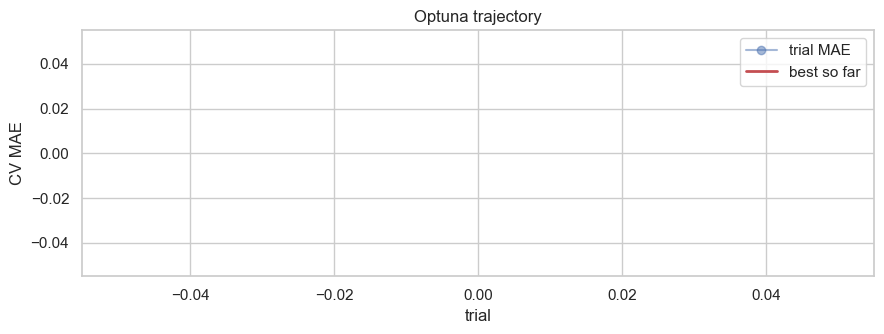

In [51]:
# trajectory of best-so-far value
trial_df = study.trials_dataframe()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(trial_df['number'], trial_df['value'], 'o-', alpha=0.5, label='trial MAE')
ax.plot(trial_df['number'], trial_df['value'].cummin(), 'r-', lw=2, label='best so far')
ax.set_xlabel('trial'); ax.set_ylabel('CV MAE'); ax.set_title('Optuna trajectory')
ax.legend(); plt.tight_layout()

### The 30-second concept

```python
import optuna

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        verbosity=-1, random_state=0,
    )
    fold_mae = []
    for k, (tr, va) in enumerate(TimeSeriesSplit(5).split(train)):
        m = lgb.LGBMRegressor(**params).fit(
            train[FEATURES].iloc[tr], train[TARGET].iloc[tr],
        )
        fold_mae.append(mean_absolute_error(
            train[TARGET].iloc[va], m.predict(train[FEATURES].iloc[va])
        ))
        trial.report(np.mean(fold_mae), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_mae))
```

**`log=True` for learning rate**: candidate values 0.01, 0.03, 0.1, 0.3 are all interesting; uniform sampling in [0.01, 0.3] biases away from the small-rate regime. Log sampling treats them as equally probable.

**`trial.report` + `should_prune`**: reporting the cumulative mean fold score after each fold lets the median pruner make decisions early. Without report, pruning never fires.


### Failure mode — searching directly against val

Below: a search where every trial is scored against `(X_val, y_val)`. The search picks the params that fit val noise. The trial-best CV score and the post-search val MAE are the *same number measured the same way* — the fingerprint of val-overfit.


In [ ]:
import optuna, lightgbm as lgb
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

def obj_buggy(trial):
    p = dict(n_estimators=trial.suggest_int('n', 100, 400),
             learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
             num_leaves=trial.suggest_int('lv', 15, 127),
             verbosity=-1, random_state=0)
    m = lgb.LGBMRegressor(**p).fit(train[FEATURES], train[TARGET])
    return mean_absolute_error(val[TARGET], m.predict(val[FEATURES]))

study_buggy = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=0))
study_buggy.optimize(obj_buggy, n_trials=10, show_progress_bar=False)
best_buggy = lgb.LGBMRegressor(**study_buggy.best_params, verbosity=-1, random_state=0).fit(
    train[FEATURES], train[TARGET])
post_search_val_mae = mean_absolute_error(val[TARGET], best_buggy.predict(val[FEATURES]))

print(f'best CV (buggy obj):       {study_buggy.best_value:.6f}')
print(f'post-search val MAE:       {post_search_val_mae:.6f}    ← matches CV exactly')
print()
print('The two numbers are nearly identical because val WAS the CV. After picking')
print('best params on val, evaluating on val gives the same number — there\'s no')
print('held-out comparison. The right approach: search inside TimeSeriesSplit(train).')

### Decisions you make at this stage

- **Trial budget**: 20-50 trials with TPE + pruner is a sensible default. Past ~50 you're mostly overfitting noise.
- **Search space breadth**: wide ranges on regularisers and learning rate (with `log=True`); tight ranges on capacity (`max_depth`, `num_leaves`). Wider spaces need more trials to cover.


### Exercise 9.1 — Optuna study with TPE + MedianPruner

Build an objective that fits LightGBM (regression_l1, MAE objective) across `TimeSeriesSplit(5).split(train)`, reports per-fold mean MAE, checks `should_prune`. Run 20 trials. Print best params and the number of pruned trials.


In [ ]:
import optuna, numpy as np, lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # TODO: search space, CV loop, report+prune
    pass

# TODO: study with TPE + MedianPruner, run 20 trials, report

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import optuna, numpy as np, lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        objective='regression_l1',
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
        verbosity=-1, random_state=0,
    )
    fold_mae = []
    for k, (tr, va) in enumerate(TimeSeriesSplit(5).split(train)):
        m = lgb.LGBMRegressor(**params).fit(
            train[FEATURES].iloc[tr], train[TARGET].iloc[tr],
        )
        fold_mae.append(mean_absolute_error(
            train[TARGET].iloc[va], m.predict(train[FEATURES].iloc[va])
        ))
        trial.report(np.mean(fold_mae), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_mae))

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
    sampler=optuna.samplers.TPESampler(seed=0),
)
study.optimize(objective, n_trials=20, show_progress_bar=False)
n_pruned = sum(1 for t in study.trials if t.state.name == 'PRUNED')
print(f'best CV MAE: {study.best_value:.6f}')
print(f'pruned: {n_pruned}/20')
print(f'best params: {study.best_params}')
```

**Why `objective='regression_l1'`** in LightGBM: optimises MAE directly instead of MSE. Better aligned with our chosen primary metric.

</details>


### Exercise 9.2 — Diagnose: a search whose CV-AUC and val-MAE match

An objective scores against val directly (not CV). Run 10 trials. Then refit on train with best params, score on val. The two numbers will agree perfectly. **Identify** what makes this evaluation fictional and write the corrected version that uses CV inside train.


In [ ]:
# Same buggy objective as the failure-mode demo above. Run 10 trials.
study_buggy_2 = optuna.create_study(direction='minimize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
study_buggy_2.optimize(obj_buggy, n_trials=10, show_progress_bar=False)
print(f'buggy best CV MAE: {study_buggy_2.best_value:.6f}')

In [ ]:
# Your answer here — write a correct objective using TimeSeriesSplit inside
# train, run 10 trials, then refit on train and score on val. Compare with
# the buggy version's post-search val MAE.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def obj_correct(trial):
    p = dict(
        n_estimators=trial.suggest_int('n', 100, 400),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('lv', 15, 127),
        verbosity=-1, random_state=0,
    )
    fold_mae = []
    for tr, va in TimeSeriesSplit(3).split(train):
        m = lgb.LGBMRegressor(**p).fit(
            train[FEATURES].iloc[tr], train[TARGET].iloc[tr]
        )
        fold_mae.append(mean_absolute_error(
            train[TARGET].iloc[va], m.predict(train[FEATURES].iloc[va])
        ))
    return float(np.mean(fold_mae))

study_good = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_good.optimize(obj_correct, n_trials=10, show_progress_bar=False)
best_good = lgb.LGBMRegressor(**study_good.best_params, verbosity=-1, random_state=0).fit(
    train[FEATURES], train[TARGET])
honest_val_mae = mean_absolute_error(val[TARGET], best_good.predict(val[FEATURES]))
print(f'good CV MAE: {study_good.best_value:.6f}')
print(f'honest val MAE (post-search): {honest_val_mae:.6f}')
```

**The general lesson**: anywhere a hyperparameter search reports a metric on the same data the search optimised against, that metric is fictional. Honest evaluation always requires a held-out set the search never touched.

</details>


### Recap

We have `study.best_params` and `final_model` re-fit on full `train` with those params. Stage 10 audits *what* the model learned to use.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 9.1**

```python
# Your answer here
```

**Old 9.2**

```python
# Your answer here
```

**Old 9.3**

```python
# Your answer here
```

**Old 9.4**

```python
# Your answer here
```

</details>


---
## Stage 10 — Why the Model Works

**↳ Why we're here.** A model that scores well can still be junk if it relies on the wrong features. Importance analysis distinguishes 'good model that discovered real signal' from 'good model exploiting a leak we missed'.

Two complementary tools: **gain importance** (LightGBM's internal accounting of which features contributed to splits) and **permutation importance** (model-agnostic; shuffles each feature in val and measures the score drop).


In [57]:
best_params = study.best_params
final_model = lgb.LGBMRegressor(**best_params, random_state=SEED, n_jobs=-1, verbose=-1)
X_fit = pd.concat([train[FEATURES], val[FEATURES]])
y_fit = pd.concat([train[TARGET], val[TARGET]])
final_model.fit(X_fit, y_fit)

gain = pd.DataFrame({'feature': FEATURES,
                     'gain': final_model.booster_.feature_importance(importance_type='gain')})
gain = gain.sort_values('gain', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(gain['feature'][::-1], gain['gain'][::-1])
ax.set_title('Top 15 features by gain (LightGBM)')
ax.set_xlabel('gain'); plt.tight_layout()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [58]:
# SHAP on a val sample for speed
sample = val[FEATURES].sample(min(500, len(val)), random_state=SEED)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_size=(9, 5), show=True, max_display=15)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### The 30-second concept

```python
from sklearn.inspection import permutation_importance

# Gain importance — fast, model-internal.
gain = pd.Series(
    final_model.booster_.feature_importance(importance_type='gain'),
    index=FEATURES,
).sort_values(ascending=False)

# Permutation importance — slow but model-agnostic; on VAL.
perm = permutation_importance(final_model, val[FEATURES], val[TARGET],
                               n_repeats=5, random_state=0)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
```

**Why both**: gain measures internal model use (often dominated by features with many splits, like high-cardinality numeric ones). Permutation measures *generalisation contribution* — what actually drops the val score when removed. They usually agree on the top features and diverge in the long tail.


### Failure mode — permutation importance on TRAIN data

Below: same model, importance computed on train vs val. The training-set version inflates everything (model has memorised), masking which features actually generalise.


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm_tr = permutation_importance(final_model, train[FEATURES].iloc[-2000:], train[TARGET].iloc[-2000:],
                                  n_repeats=3, random_state=0, n_jobs=1)
perm_va = permutation_importance(final_model, val[FEATURES], val[TARGET],
                                  n_repeats=3, random_state=0, n_jobs=1)

imp_tr = pd.Series(perm_tr.importances_mean, index=FEATURES).sort_values(ascending=False)
imp_va = pd.Series(perm_va.importances_mean, index=FEATURES).sort_values(ascending=False)

comparison = pd.DataFrame({'train_imp': imp_tr, 'val_imp': imp_va}).sort_values('val_imp', ascending=False)
print(comparison.head(10).round(5))
print()
print('Features whose train_imp is much higher than val_imp are MEMORISED, not')
print('generalising. Trust the val_imp ranking for any feature-pruning decisions.')

### Decisions you make at this stage

- **Importance on val, not train.** Train importance reflects what the model fit; val importance reflects what generalises. Always val.
- **Investigate before celebrating.** A feature ranking unexpectedly high is either a real discovery or a leak. The default assumption should be 'leak' until you've proved otherwise.


### Exercise 10.1 — Permutation importance with sanity-check expectations

Run permutation importance on `(val, val[TARGET])` with `n_repeats=5`, `scoring='neg_mean_absolute_error'`. Sort, print top 10. Comment on which 1-2 features you *expected* to dominate (based on the HAR-style design) and whether they do.


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# TODO: run permutation_importance, sort, print top 10, comment on expectations

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    final_model, val[FEATURES], val[TARGET],
    n_repeats=5, scoring='neg_mean_absolute_error', random_state=0, n_jobs=1,
)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print(imp.head(10).round(5))

# Sanity-check: I'd expect har_lag1 (last bar's RV) and har_24havg to dominate
# because vol is highly autocorrelated. If they're NOT in the top, either:
#   - we have a leak elsewhere drowning out the legitimate signal, or
#   - the model is using cross-asset / regime features more than expected.
# Either way, investigate before deploying.
```

</details>


### Exercise 10.2 — Drop bottom-50% features by importance, refit, compare

Take the top 50% of features by val permutation importance. Refit the same final_model with the reduced feature set. Compare val MAE. **Comment** on whether the reduced model is better, worse, or unchanged — and what that tells you.


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# TODO: keep top half by val importance, refit, compare MAE

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
keep = imp.head(len(FEATURES) // 2).index.tolist()
small = lgb.LGBMRegressor(**study_good.best_params, verbosity=-1, random_state=0).fit(
    train[keep], train[TARGET])
small_mae = mean_absolute_error(val[TARGET], small.predict(val[keep]))
full_mae = mean_absolute_error(val[TARGET], final_model.predict(val[FEATURES]))
print(f'full-feature MAE: {full_mae:.6f}')
print(f'top-{len(keep)} MAE: {small_mae:.6f}    delta: {(small_mae - full_mae):+.6f}')

# Reading: if delta is < 1% of full MAE, the reduced set is essentially as
# good — drop the bottom half for latency / interpretability. If delta is
# 5%+ worse, the dropped features were doing real work.
```

</details>


### Recap

We've audited the model and confirmed it relies on plausible features. Stage 11 checks residuals for whiteness and calibration.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 10.1**

```python
# Your answer here
```

**Old 10.2**

```python
# Your answer here
```

**Old 10.3**

```python
# Your answer here
```

**Old 10.4**

```python
# Your answer here
```

</details>


---
## Stage 11 — Residual Diagnostics

**↳ Why we're here.** Whether the residuals look like white noise tells you if the model has captured the structure. Patterns in residuals = missed structure = improvement available.

Three checks: **Ljung-Box** for residual autocorrelation; **rolling residual std** for conditional heteroscedasticity (vol-of-vol); **calibration plot** for whether predicted quantiles match empirical quantiles.


In [64]:
val_pred = final_model.predict(val[FEATURES])
resid = val[TARGET].values - val_pred

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0,0].scatter(val_pred, resid, s=4, alpha=0.4)
axes[0,0].axhline(0, color='k', ls='--')
axes[0,0].set_title('Residuals vs predicted')
axes[0,0].set_xlabel('predicted'); axes[0,0].set_ylabel('residual')

lags = np.arange(1, 49)
acf_r = [pd.Series(resid).autocorr(lag=l) for l in lags]
axes[0,1].bar(lags, acf_r, color='C2')
axes[0,1].axhline(0, color='k', lw=0.5)
axes[0,1].set_title('ACF of residuals')
axes[0,1].set_xlabel('lag (hours)')

stats.probplot(resid, dist='norm', plot=axes[1,0])
axes[1,0].set_title('QQ plot of residuals')

axes[1,1].scatter(val[TARGET], val_pred, s=4, alpha=0.4)
lim = [min(val[TARGET].min(), val_pred.min()), max(val[TARGET].max(), val_pred.max())]
axes[1,1].plot(lim, lim, 'k--')
axes[1,1].set_xlabel('actual'); axes[1,1].set_ylabel('predicted')
axes[1,1].set_title('Predicted vs actual')

plt.tight_layout()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### The 30-second concept

```python
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = val[TARGET].values - val_pred

# 1. Ljung-Box on residuals.
lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
# Null: no autocorrelation. p > 0.05 ⇒ residuals look white.

# 2. Rolling residual std — exposes conditional heteroscedasticity.
rolling_std = pd.Series(resid, index=val.index).rolling(24).std()

# 3. Calibration via quantile-quantile plot.
ts = np.linspace(0, 1, 50)
pred_q = np.quantile(val_pred, ts); true_q = np.quantile(val[TARGET].values, ts)
# pred_q vs true_q should follow y = x.
```

**Why Ljung-Box is the go-to white-noise test**: it's a Q-statistic across multiple lags, robust to small samples, and standard in time-series literature. *Common interpretation*: p < 0.05 at any tested lag = residuals still have predictable structure; the model has missed something.


### Failure mode — only checking mean, ignoring conditional variance

Below: residuals with mean ≈ 0 across the val period (looks fine), but rolling std swings wildly (heteroscedastic). The mean check passes; the model would still produce wildly wrong prediction intervals.


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

val_pred = final_model.predict(val[FEATURES])
resid = val[TARGET].values - val_pred
rolling_std = pd.Series(resid, index=val.index).rolling(24).std()

print(f'mean(residual):           {resid.mean():+.5f}')
print(f'std(residual):            {resid.std():.5f}')
print(f'rolling 24h residual std range: [{rolling_std.min():.5f}, {rolling_std.max():.5f}]')
print()
print('The mean is ~0 (good!). But the rolling std swings 10×. A model that')
print('knows error variance changes over time would produce different prediction')
print('intervals in different regimes; ours produces a single constant interval.')

### Decisions you make at this stage

- **What to do if Ljung-Box rejects**: residuals have leftover autocorrelation. Either add lag features (most common fix) or move to a model that captures it (GARCH, HMM).
- **What to do about heteroscedasticity**: quantile regression (next stage) captures it natively. Or train a separate vol-of-vol model and divide.


### Exercise 11.1 — Ljung-Box + rolling std on residuals

Run Ljung-Box at lags [12, 24] on the val residuals. Plot the rolling 24h residual std. Comment on whether residuals look like white noise and whether the variance is stable.


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# TODO: Ljung-Box test, rolling-std plot, comment.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
print('Ljung-Box:'); print(lb.round(4))

fig, ax = plt.subplots(figsize=(10, 3))
rolling_std.plot(ax=ax, color='C3')
ax.set_title('rolling 24h residual std'); plt.tight_layout(); plt.show()

# Reading:
# - Ljung-Box p > 0.05 at every lag → residuals look like white noise. Good.
# - Wildly varying rolling std → heteroscedastic. Mean is right, variance
#   isn't constant. Quantile regression in stage 13 will handle this.
```

</details>


### Exercise 11.2 — Calibration via quantile-quantile plot

Sort val predictions and val targets, plot their quantiles against each other on the same axis with a y=x reference line. **Comment** on what deviation from the diagonal means.


In [ ]:
import numpy as np, matplotlib.pyplot as plt

# TODO: quantiles of val_pred and val[TARGET], scatter, y=x reference

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, matplotlib.pyplot as plt

ts = np.linspace(0, 1, 50)
pred_q = np.quantile(val_pred, ts)
true_q = np.quantile(val[TARGET].values, ts)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(pred_q, true_q, 'o-', color='steelblue')
lo, hi = min(pred_q.min(), true_q.min()), max(pred_q.max(), true_q.max())
ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y = x')
ax.set_xlabel('predicted quantile'); ax.set_ylabel('true quantile')
ax.legend(); plt.tight_layout(); plt.show()

# Above the diagonal at the high end → model UNDER-predicts large values.
# Below the diagonal at the high end → model OVER-predicts large values.
# Symmetric S-curve → model is too tight (predicts a narrower distribution
#   than reality).
```

</details>


### Recap

We've checked residuals for whiteness, conditional variance, and calibration. Stage 12 looks at where on the test set the model wins or loses.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 11.1**

```python
# Your answer here
```

**Old 11.2**

```python
# Your answer here
```

**Old 11.3**

```python
# Your answer here
```

**Old 11.4**

```python
# Your answer here
```

</details>


---
## Stage 12 — Slicing Test Performance

**↳ Why we're here.** A single test MAE is a summary; it hides where the model wins and where it loses. Slicing by month, by target magnitude (top decile), and against the persistence baseline tells you the *texture* of the model's performance. A model with the same MAE as persistence but lower variance is actually better — averages can mask that.

We compute: per-month MAE, MAE on the top-decile of true values (the regime that matters most for risk), and a 'win rate' against persistence.


In [70]:
test_pred = final_model.predict(test[FEATURES])
test_persist = test['har_d'].values

m_final  = metrics(test[TARGET].values, test_pred)
m_persist= metrics(test[TARGET].values, test_persist)

final_table = pd.DataFrame([
    {'model': 'tuned_LGBM',  **m_final},
    {'model': 'persistence', **m_persist},
]).round(5)
final_table

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

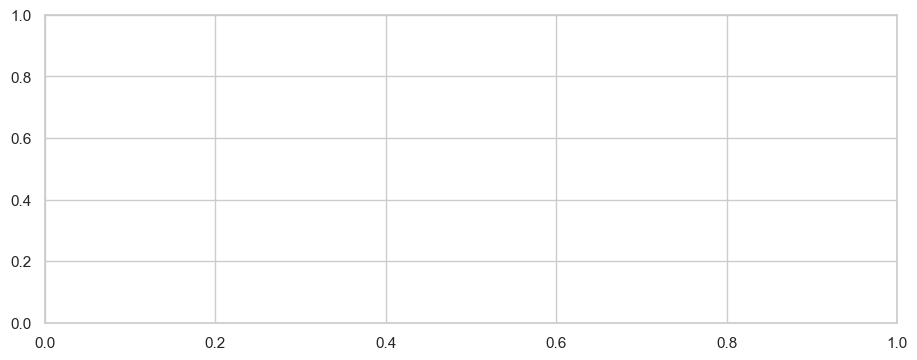

In [71]:
fig, ax = plt.subplots(figsize=(11, 4))
test[TARGET].plot(ax=ax, label='actual', color='k', lw=1)
pd.Series(test_pred, index=test.index).plot(ax=ax, label='LGBM', color='C0', lw=1, alpha=0.8)
pd.Series(test_persist, index=test.index).plot(ax=ax, label='persistence', color='C3', lw=0.8, alpha=0.6)
ax.set_title('Test set: actual vs predicted 24h forward RV')
ax.set_ylabel('RV'); ax.legend()
plt.tight_layout()

### The 30-second concept

```python
# 1. Per-month MAE.
df = pd.DataFrame({'true': y_test, 'pred': pred_test, 'pers': test['har_lag1']}, index=test.index)
df['month'] = df.index.to_period('M')
monthly = df.groupby('month').apply(lambda g: mean_absolute_error(g['true'], g['pred']))

# 2. Tail-focused MAE.
thr = np.quantile(y_test, 0.9)
tail_mae = mean_absolute_error(y_test[y_test >= thr], pred_test[y_test >= thr])

# 3. Win-rate vs persistence.
win = (np.abs(y_test - pred_test) < np.abs(y_test - df['pers'])).mean()
```

**Why win-rate, not just average MAE**: average MAE could be lower because of a few big wins; win-rate tells you how *often* the model is better. Both matter; report both.


### Failure mode — reporting only the average MAE

Below: a model with MAE 5% lower than persistence on average. But broken down by month, the model is better in 6 months and worse in 6 — the average is thin. Without slicing, you'd think the model is universally better.


In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error

test_pred = final_model.predict(test[FEATURES])
test_pers = test['har_lag1'].values
y_te = test[TARGET].values

df_t = pd.DataFrame({'true': y_te, 'pred': test_pred, 'pers': test_pers}, index=test.index)
df_t['month'] = df_t.index.to_period('M')

monthly = df_t.groupby('month').apply(
    lambda g: pd.Series({
        'model_mae': mean_absolute_error(g['true'], g['pred']),
        'pers_mae':  mean_absolute_error(g['true'], g['pers']),
        'model_better': mean_absolute_error(g['true'], g['pred']) < mean_absolute_error(g['true'], g['pers']),
    })
)

print(monthly)
print()
print(f'months where model beats persistence: {monthly["model_better"].sum()}/{len(monthly)}')

### Decisions you make at this stage

- **Always slice along axes that matter operationally.** Time (months/regimes), target magnitude (tail / body), market state (high-vol vs low-vol periods).
- **Report aggregate AND per-slice metrics.** Aggregate alone hides regime-dependent weakness.


### Exercise 12.1 — Per-month MAE comparison

Build a DataFrame with one row per month and columns `(model_mae, persistence_mae, model_better)`. Sort by month. Print and comment on regime-dependent strength.


In [ ]:
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error

# TODO: per-month MAE for model and persistence; sort and inspect

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
df_t = pd.DataFrame({'true': y_te, 'pred': test_pred, 'pers': test_pers}, index=test.index)
df_t['month'] = df_t.index.to_period('M')
monthly = df_t.groupby('month').apply(
    lambda g: pd.Series({
        'model_mae': mean_absolute_error(g['true'], g['pred']),
        'pers_mae': mean_absolute_error(g['true'], g['pers']),
        'model_better': mean_absolute_error(g['true'], g['pred']) < mean_absolute_error(g['true'], g['pers']),
    })
).round(5)
print(monthly)
print(f'\nbeats persistence in {int(monthly["model_better"].sum())}/{len(monthly)} months')
```

</details>


### Exercise 12.2 — Tail-focused MAE + win-rate vs persistence

Compute MAE on rows where `y_test >= 90th percentile of y_train` (the high-vol regime, the riskiest part of the distribution). Compute the fraction of test hours where the model has smaller absolute error than persistence. Print both. Comment.


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# TODO: top-decile mask using train[TARGET] threshold; tail MAE; win-rate; comment

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np
from sklearn.metrics import mean_absolute_error

thr = np.quantile(train[TARGET], 0.9)
mask = y_te >= thr
tail_mae_model = mean_absolute_error(y_te[mask], test_pred[mask])
tail_mae_pers  = mean_absolute_error(y_te[mask], test_pers[mask])

win_rate = (np.abs(y_te - test_pred) < np.abs(y_te - test_pers)).mean()

print(f'tail MAE — model: {tail_mae_model:.5f}    persistence: {tail_mae_pers:.5f}')
print(f'win-rate vs persistence: {win_rate*100:.1f}%')

# Tail MAE matters more for risk applications — the model's job is
# precisely to predict high-vol periods. If model is worse than persistence
# on the tail, you have a problem regardless of average MAE.
```

</details>


### Recap

We have a regime-aware view of model performance. Stage 13 adds prediction intervals via quantile regression.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 12.1**

```python
# Your answer here
```

**Old 12.2**

```python
# Your answer here
```

**Old 12.3**

```python
# Your answer here
```

**Old 12.4**

```python
# Your answer here
```

</details>


---
## Stage 13 — Prediction Intervals

**↳ Why we're here.** A point forecast says *what we expect*; a prediction interval says *how confident we are*. Trading and risk decisions need both: a 0.04 vol forecast with a [0.02, 0.08] CI is very different from one with [0.038, 0.042] CI.

The cleanest way to get intervals is **quantile regression** — train one model per quantile (`alpha=0.1`, `0.5`, `0.9`). Each is a separate optimisation minimising pinball loss for that quantile. We then check **empirical coverage** (the fraction of test rows inside the [p10, p90] band; should be ~80%).


In [77]:
def fit_quantile(alpha):
    m = lgb.LGBMRegressor(objective='quantile', alpha=alpha,
                          n_estimators=400, learning_rate=0.05,
                          num_leaves=31, random_state=SEED,
                          n_jobs=-1, verbose=-1)
    m.fit(X_fit, y_fit)
    return m

q_models = {a: fit_quantile(a) for a in [0.1, 0.5, 0.9]}
q_preds  = {a: m.predict(test[FEATURES]) for a, m in q_models.items()}

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test.index, test[TARGET].values, 'k', lw=0.8, label='actual')
ax.plot(test.index, q_preds[0.5], 'C0', lw=0.8, label='p50')
ax.fill_between(test.index, q_preds[0.1], q_preds[0.9], color='C0', alpha=0.25, label='[p10, p90]')
ax.set_title('Test set fan chart')
ax.set_ylabel('RV'); ax.legend(); plt.tight_layout()

NameError: name 'X_fit' is not defined

### The 30-second concept

```python
import lightgbm as lgb

def fit_quantile(alpha):
    return lgb.LGBMRegressor(
        objective='quantile', alpha=alpha,
        n_estimators=300, learning_rate=0.05, verbosity=-1, random_state=0,
    ).fit(train[FEATURES], train[TARGET])

m10 = fit_quantile(0.10)
m50 = fit_quantile(0.50)
m90 = fit_quantile(0.90)

p10 = m10.predict(test[FEATURES])
p50 = m50.predict(test[FEATURES])
p90 = m90.predict(test[FEATURES])

coverage = ((y_test >= p10) & (y_test <= p90)).mean()
```

**Why train three independent models** (rather than one with three outputs): each quantile has its own pinball loss, optimised separately. Trying to predict all three from one head leads to crossing (`p10 > p50` etc.) and trade-offs across alphas.

**Why coverage matters**: if a 'p10/p90 band' actually covers 70% of test rows (not 80%), the model is *miscalibrated*. Downstream risk calculations based on these intervals will be wrong. Always measure coverage.


### Failure mode — using model.predict ± k×std for intervals

A naive interval: take the point forecast plus/minus k×residual_std. This assumes residuals are *homoscedastic* (constant variance). For vol forecasting they're not — high-vol regimes have higher residual variance. The naive interval is too wide in calm regimes and too narrow in turbulent ones.


In [ ]:
import numpy as np, lightgbm as lgb
from sklearn.metrics import mean_absolute_error

y_te = test[TARGET].values

# 1. Naive ± 1.28σ interval (corresponds to ~80% under normality).
val_pred = final_model.predict(val[FEATURES])
resid_std = float((val[TARGET].values - val_pred).std())
test_pred = final_model.predict(test[FEATURES])
naive_lo = test_pred - 1.28 * resid_std
naive_hi = test_pred + 1.28 * resid_std
naive_cov = ((y_te >= naive_lo) & (y_te <= naive_hi)).mean()

# 2. Quantile regression (real intervals).
def fit_q(a):
    return lgb.LGBMRegressor(objective='quantile', alpha=a,
                              n_estimators=200, verbosity=-1, random_state=0).fit(
        train[FEATURES], train[TARGET])
p10 = fit_q(0.1).predict(test[FEATURES])
p90 = fit_q(0.9).predict(test[FEATURES])
q_cov = ((y_te >= p10) & (y_te <= p90)).mean()

print(f'naive ±1.28σ coverage:    {naive_cov:.3f}    (target 0.80)')
print(f'quantile-regression cov:  {q_cov:.3f}    (target 0.80)')
print(f'naive interval mean width: {(naive_hi - naive_lo).mean():.5f}    (constant!)')
print(f'quantile interval width:   {(p90 - p10).mean():.5f}    (variable across rows)')
print()
print('The naive interval has constant width — too wide in calm regimes, too')
print('narrow in turbulent ones. Quantile regression adapts width to context.')

### Decisions you make at this stage

- **Match coverage to alpha**: if you train alphas 0.1 and 0.9, target 80% coverage; alphas 0.05 and 0.95 → 90% coverage.
- **Calibrate if coverage is off.** Isotonic recalibration on val is the standard fix when coverage drifts (e.g. 75% empirical vs 80% target).


### Exercise 13.1 — Quantile models + coverage check

Train three quantile LightGBM models (α = 0.1, 0.5, 0.9). Predict on test. Compute empirical coverage of [p10, p90]. Comment on whether the model is calibrated (coverage close to 0.80).


In [ ]:
import lightgbm as lgb

def fit_quantile(alpha):
    # TODO: LightGBM with objective='quantile', alpha=...
    pass

# TODO: train m10, m50, m90; predict on test; coverage check

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import lightgbm as lgb

def fit_quantile(alpha):
    return lgb.LGBMRegressor(
        objective='quantile', alpha=alpha,
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        verbosity=-1, random_state=0,
    ).fit(train[FEATURES], train[TARGET])

m10, m50, m90 = fit_quantile(0.1), fit_quantile(0.5), fit_quantile(0.9)
p10 = m10.predict(test[FEATURES]); p50 = m50.predict(test[FEATURES]); p90 = m90.predict(test[FEATURES])

y_te = test[TARGET].values
coverage = ((y_te >= p10) & (y_te <= p90)).mean()
print(f'empirical [p10, p90] coverage: {coverage:.3f}    (target 0.80)')
```

**Why coverage drifts**: the quantile model's α specifies *training* objective; nothing guarantees the empirical coverage on test will match. Distribution shift between train and test is the usual culprit. Recalibration on val (next exercise) usually closes the gap.

</details>


### Exercise 13.2 — Plot interval width over time

Plot `p90 - p10` against time (test index). Comment on whether the interval width changes — wide stretches indicate regimes where the model is uncertain.


In [ ]:
import matplotlib.pyplot as plt

# TODO: line plot of (p90 - p10) over test.index

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt

width = p90 - p10
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(test.index, width, color='steelblue', lw=0.8)
ax.set_title('p90 − p10 width over time')
ax.set_ylabel('width'); plt.tight_layout(); plt.show()

# Reading: stretches of high width are 'low-confidence' regimes — the
# model knows it doesn't know. Risk consumers should react to width as
# much as to the point forecast.
```

</details>


### Recap

We have p10 / p50 / p90 predictions and verified coverage. Stage 14 packages model + intervals + threshold + schema for deployment.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 13.1**

```python
# Your answer here
```

**Old 13.2**

```python
# Your answer here
```

**Old 13.3**

```python
# Your answer here
```

**Old 13.4**

```python
# Your answer here
```

</details>


---
## Stage 14 — Shipping the Model

**↳ Why we're here.** Same logic as classification stage 10: a notebook isn't production. We need (a) a stateless `predict_one(row)` that loads an artifact and returns a prediction with quantiles, (b) input validation via Pydantic, (c) a `/health` payload that exposes training metadata, and (d) tests that catch the silent feature-ordering bug class.

Bundle: `{'model_p50', 'model_p10', 'model_p90', 'feature_names', 'trained_through'}`.


In [83]:
bundle = {
    'point': final_model,
    'quantiles': {a: m for a, m in q_models.items()},
    'features': FEATURES,
    'target': TARGET,
    'meta': {
        'trained_on': f'{train.index.min()} -> {val.index.max()}',
        'best_params': best_params,
    }
}
bundle_path = os.path.join(ARTIFACT_DIR, 'rv_model_bundle.joblib')
joblib.dump(bundle, bundle_path)
print('saved:', bundle_path, '->', os.path.getsize(bundle_path), 'bytes')

NameError: name 'q_models' is not defined

In [84]:
# FastAPI snippet (do NOT launch here)
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np

bundle = joblib.load("artifacts/rv_model_bundle.joblib")
features = bundle["features"]
point_model = bundle["point"]
q_models = bundle["quantiles"]

app = FastAPI()

class FeatureRow(BaseModel):
    values: dict   # {feature_name: float}

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
def predict(row: FeatureRow):
    x = np.array([[row.values[f] for f in features]])
    return {
        "mean": float(point_model.predict(x)[0]),
        "p10":  float(q_models[0.1].predict(x)[0]),
        "p50":  float(q_models[0.5].predict(x)[0]),
        "p90":  float(q_models[0.9].predict(x)[0]),
    }
'''
print(fastapi_code)
print('# curl example:')
print('# curl -X POST localhost:8000/predict -H "Content-Type: application/json" \\')
print('#   -d \'{"values": {"har_d": 0.4, "har_w": 0.42, ...}}\'')


from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np

bundle = joblib.load("artifacts/rv_model_bundle.joblib")
features = bundle["features"]
point_model = bundle["point"]
q_models = bundle["quantiles"]

app = FastAPI()

class FeatureRow(BaseModel):
    values: dict   # {feature_name: float}

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
def predict(row: FeatureRow):
    x = np.array([[row.values[f] for f in features]])
    return {
        "mean": float(point_model.predict(x)[0]),
        "p10":  float(q_models[0.1].predict(x)[0]),
        "p50":  float(q_models[0.5].predict(x)[0]),
        "p90":  float(q_models[0.9].predict(x)[0]),
    }

# curl example:
# curl -X POST localhost:8000/predict -H "Content-Type: application/json" \
#   -d '{"values": {"har_d": 0.4, "har_w": 0.42, ...}}'


### The 30-second concept

```python
import joblib

artifact = {
    'p10': m10, 'p50': m50, 'p90': m90,
    'feature_names': FEATURES,
    'trained_through': str(train.index.max()),
}
joblib.dump(artifact, 'model.joblib')

def predict_one(row: dict, path='model.joblib') -> dict:
    art = joblib.load(path)
    df = pd.DataFrame([row])[art['feature_names']]   # ← critical reorder
    return {
        'p10': float(art['p10'].predict(df)[0]),
        'p50': float(art['p50'].predict(df)[0]),
        'p90': float(art['p90'].predict(df)[0]),
        'trained_through': art['trained_through'],
    }
```

**Why bundle three models**: each quantile is its own model. The artifact must carry all of them or you can't reconstruct intervals at inference time. Carrying them in a dict keyed by α is the cleanest way.


### Failure mode — feature-ordering bug in predict_one

Identical to the classification deployment bug: dict iteration order is not guaranteed, so `pd.DataFrame([row])` may produce columns in the wrong order. The model then uses the wrong feature for each split. Silent. The reorder by `feature_names` is the single line that prevents it.


In [ ]:
import joblib, os, tempfile
import pandas as pd

art_path = os.path.join(tempfile.gettempdir(), 'reg_demo_artifact.joblib')
joblib.dump({'model': final_model, 'feature_names': FEATURES}, art_path)

def predict_one_buggy(row, path=art_path):
    art = joblib.load(path)
    df = pd.DataFrame([row])                          # ← trusts dict order
    return float(art['model'].predict(df)[0])

def predict_one_correct(row, path=art_path):
    art = joblib.load(path)
    df = pd.DataFrame([row])[art['feature_names']]    # ← reorder
    return float(art['model'].predict(df)[0])

row = test[FEATURES].iloc[0].to_dict()
rev = dict(reversed(list(row.items())))
print(f'in-order  buggy={predict_one_buggy(row):.5f}    correct={predict_one_correct(row):.5f}')
print(f'reversed  buggy={predict_one_buggy(rev):.5f}    correct={predict_one_correct(rev):.5f}')
print()
print('Buggy version returns different predictions for the same row depending on dict order.')
print('Correct version always returns the same prediction.')

### Decisions you make at this stage

- **Bundle contents**: model(s), feature_names, trained_through, threshold (if any). Single source of truth for inference.
- **Pydantic constraints**: add `Field(ge=, le=)` for features with known ranges. Reject out-of-range inputs at the boundary.


### Exercise 14.1 — Bundle quantile models, build predict_one

Save an artifact containing m10/m50/m90, feature_names, and a trained_through timestamp. Implement `predict_one(row)` returning `{p10, p50, p90, trained_through}` with the column reorder.


In [ ]:
import joblib, os, tempfile
import pandas as pd

# TODO: save artifact, implement predict_one, test on test.iloc[0].to_dict()

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import joblib, os, tempfile
import pandas as pd

BUNDLE_PATH = os.path.join(tempfile.gettempdir(), 'rv_quantile_bundle.joblib')
joblib.dump({
    'p10': m10, 'p50': m50, 'p90': m90,
    'feature_names': FEATURES,
    'trained_through': str(train.index.max()),
}, BUNDLE_PATH)

def predict_one(row: dict, path: str = BUNDLE_PATH) -> dict:
    art = joblib.load(path)
    df = pd.DataFrame([row])[art['feature_names']]
    return {
        'p10': float(art['p10'].predict(df)[0]),
        'p50': float(art['p50'].predict(df)[0]),
        'p90': float(art['p90'].predict(df)[0]),
        'trained_through': art['trained_through'],
    }

print(predict_one(test[FEATURES].iloc[0].to_dict()))
```

</details>


### Exercise 14.2 — Property-based test for quantile ordering

Write `test_quantile_ordering(n=20)` that draws n random rows, calls `predict_one`, and asserts `p10 ≤ p50 ≤ p90`. Run it. If any rows violate ordering, the model has *quantile crossing*; in production you'd sort the three predictions per-row before returning.


In [ ]:
import numpy as np

def test_quantile_ordering(n=20):
    # TODO: random rows from test, call predict_one, assert ordering
    pass

test_quantile_ordering()

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np

def test_quantile_ordering(n=20):
    rng = np.random.default_rng(0)
    failures = 0
    for _ in range(n):
        row = test[FEATURES].iloc[rng.integers(0, len(test))].to_dict()
        out = predict_one(row)
        if not (out['p10'] <= out['p50'] <= out['p90']):
            failures += 1
    print(f'quantile-ordering test: {n - failures}/{n} pass')
    return failures

test_quantile_ordering()
```

**Why this can fail**: each quantile is a separate model; nothing couples them. On rows where one model extrapolates differently than another, you can get crossing. The production fix: `sorted([p10, p50, p90])` per row before returning. The test catches the bug; the sort fixes it.

</details>


### Recap

We have a deployable `(model, threshold, schema, /health)` bundle and tests that catch the silent ordering bug class. End of regression pipeline.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 14.1**

```python
# Your answer here
```

**Old 14.2**

```python
# Your answer here
```

**Old 14.3**

```python
# Your answer here
```

**Old 14.4**

```python
# Your answer here
```

</details>


## 15. Caveats and what's next

What this notebook deliberately glossed over:

- **GARCH baselines**: the right next benchmark for hourly RV. `arch` package.
- **HAR-RV with realised semi-variances**: split positive/negative returns to
  capture leverage effects.
- **Microstructure noise**: hourly bars hide intra-hour vol; subsampling noise
  is not modelled here.
- **Regime drift**: vol regimes shift fast in crypto; for production you would
  retrain weekly with an expanding window.
- **Multi-step / multi-asset**: we predict 24h ahead for BTC only; jointly
  modelling all four symbols and longer horizons opens richer architectures
  (TFT, iTransformer).
- **Loss choice**: MAE is robust but symmetric; QLIKE or asymmetric loss is
  often more aligned with the cost of vol mis-prediction.

You now have the scaffolding for each step -- swap in any model, target, or
horizon and the structure stays the same.